In [14]:
import os
import cv2
import numpy as np
import scipy.io as sio
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# =========================================================
# SETTINGS
# =========================================================

BASE_PATH = r"D:\PROJECT\Dataset\csi_data2d\train"

FS = 20
NFFT = 128
NPERSEG = 40
HOP = 10
IMG_SIZE = 32
NUM_CLASSES = 6

# =========================================================
# LOAD FILE PATHS
# =========================================================

file_paths = []
labels = []

for folder in sorted(os.listdir(BASE_PATH), key=lambda x: int(x)):

    folder_path = os.path.join(BASE_PATH, folder)

    if not os.path.isdir(folder_path):
        continue

    label = int(folder) - 1

    for fname in os.listdir(folder_path):

        if fname.endswith(".mat"):

            file_paths.append(
                os.path.join(folder_path, fname)
            )

            labels.append(label)

file_paths = np.array(file_paths)
labels = np.array(labels)

print("Total Samples:", len(file_paths))

# =========================================================
# SPLIT DATA (70 / 15 / 15)
# =========================================================

train_paths, temp_paths, y_train, y_temp = train_test_split(
    file_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

val_paths, test_paths, y_val, y_test = train_test_split(
    temp_paths,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

# =========================================================
# LOAD MI SCORES
# =========================================================

mi = np.load("mi_scores.npy")

# =========================================================
# CNN MODEL
# =========================================================

def build_cnn(input_shape):

    inp = layers.Input(shape=input_shape)

    x = layers.Conv2D(
        32, 3,
        padding="same",
        activation="relu"
    )(inp)

    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(
        64, 3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(
        128, 3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    x = layers.Dropout(0.5)(x)

    out = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    return models.Model(inp, out)

# =========================================================
# CALLBACKS
# =========================================================

callbacks = [

    EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        verbose=1
    )
]

# =========================================================
# BANDWIDTH RATIOS
# =========================================================

bandwidth_ratios = [
    0.10,
    0.15,
    0.20,
    0.2442,
    0.30,
    0.40,
    1.00
]

results = []

# =========================================================
# LOOP OVER RATIOS
# =========================================================

for BW_RATIO in bandwidth_ratios:

    print("\n" + "="*60)
    print(f"Bandwidth Ratio = {BW_RATIO:.4f}")
    print("="*60)

    TOP_K = int(round(BW_RATIO * 135))

    top_subcarriers = np.argsort(mi)[::-1][:TOP_K]
    top_subcarriers = np.sort(top_subcarriers)

    print(f"Using {TOP_K}/135 subcarriers")

    # -----------------------------------------------------

    def load_csi_complex(mat_path):

        mat = sio.loadmat(mat_path)
        csi = mat["csi_1"]

        return csi[:,0::2] + 1j*csi[:,1::2]

    def stft_tensor(pdiff_sel):

        T,S = pdiff_sel.shape

        window = np.hanning(NPERSEG)

        frames = []

        for start in range(
            0,
            T-NPERSEG+1,
            HOP
        ):

            seg = pdiff_sel[start:start+NPERSEG,:]
            seg = seg * window[:,None]

            X = np.fft.rfft(
                seg,
                n=NFFT,
                axis=0
            )

            P = np.abs(X)**2
            P[0,:] = 0

            frames.append(P)

        P3 = np.stack(frames, axis=0)

        return np.transpose(P3,(1,0,2))

    def doppler_image(mat_path):

        csi = load_csi_complex(mat_path)

        phase = np.unwrap(
            np.angle(csi),
            axis=0
        )

        pdiff = np.diff(
            phase,
            axis=0
        )

        pdiff_sel = pdiff[:, top_subcarriers]

        P = stft_tensor(pdiff_sel)

        P[:2,:,:] = 0
        P[-2:,:,:] = 0

        P = np.log1p(5.0 * P)

        img = cv2.resize(
            P,
            (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_AREA
        )

        return img.astype(np.float32)

    def build_dataset(paths, labels):

        X = []
        y = []

        for p,l in zip(paths, labels):

            try:

                X.append(
                    doppler_image(p)
                )

                y.append(l)

            except:
                pass

        return np.array(X), np.array(y)

    print("Building dataset...")

    X_train, y_train_new = build_dataset(train_paths, y_train)
    X_val, y_val_new     = build_dataset(val_paths, y_val)
    X_test, y_test_new   = build_dataset(test_paths, y_test)

    mean = X_train.mean(
        axis=(0,1,2),
        keepdims=True
    )

    std = X_train.std(
        axis=(0,1,2),
        keepdims=True
    ) + 1e-6

    X_train = (X_train - mean) / std
    X_val   = (X_val - mean) / std
    X_test  = (X_test - mean) / std

    model = build_cnn(
        X_train.shape[1:]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(3e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train_new,
        validation_data=(X_val, y_val_new),
        epochs=50,
        batch_size=64,
        callbacks=callbacks,
        verbose=1
    )

    train_acc = model.evaluate(
        X_train,
        y_train_new,
        verbose=0
    )[1]

    val_acc = model.evaluate(
        X_val,
        y_val_new,
        verbose=0
    )[1]

    test_acc = model.evaluate(
        X_test,
        y_test_new,
        verbose=0
    )[1]

    print(
        f"Train={train_acc:.4f} | "
        f"Val={val_acc:.4f} | "
        f"Test={test_acc:.4f}"
    )

    results.append([
        BW_RATIO,
        TOP_K,
        train_acc,
        val_acc,
        test_acc
    ])

# =========================================================
# FINAL SUMMARY
# =========================================================

print("\n\n=== FINAL SUMMARY ===")

print(
    "{:<10} {:<14} {:<12} {:<12} {:<12}".format(
        "Ratio",
        "Subcarriers",
        "TrainAcc",
        "ValAcc",
        "TestAcc"
    )
)

for r in results:

    print(
        "{:<10.4f} {:<14d} {:<12.4f} {:<12.4f} {:<12.4f}".format(
            r[0],
            r[1],
            r[2],
            r[3],
            r[4]
        )
    )

Total Samples: 4146
Train: 2902
Val: 622
Test: 622

Bandwidth Ratio = 0.1000
Using 14/135 subcarriers
Building dataset...
Epoch 1/50
46/46 [==============================] - 5s 89ms/step - loss: 1.7007 - accuracy: 0.2905 - val_loss: 1.7178 - val_accuracy: 0.3585 - lr: 3.0000e-04
Epoch 2/50
46/46 [==============================] - 2s 44ms/step - loss: 1.4848 - accuracy: 0.3880 - val_loss: 1.6445 - val_accuracy: 0.4051 - lr: 3.0000e-04
Epoch 3/50
46/46 [==============================] - 2s 44ms/step - loss: 1.4058 - accuracy: 0.4307 - val_loss: 1.5678 - val_accuracy: 0.3939 - lr: 3.0000e-04
Epoch 4/50
46/46 [==============================] - 2s 47ms/step - loss: 1.3348 - accuracy: 0.4714 - val_loss: 1.4718 - val_accuracy: 0.4357 - lr: 3.0000e-04
Epoch 5/50
46/46 [==============================] - 2s 51ms/step - loss: 1.2680 - accuracy: 0.5052 - val_loss: 1.3667 - val_accuracy: 0.4727 - lr: 3.0000e-04
Epoch 6/50
46/46 [==============================] - 2s 48ms/step - loss: 1.2168 - accura

In [15]:
# ==========================================
# SAVE MODEL
# ==========================================

model.save("slimsense_40percent_model.keras")

np.save("selected_subcarriers_40.npy", top_subcarriers)
np.save("mean_40.npy", mean)
np.save("std_40.npy", std)

print("\n40% model saved successfully")


40% model saved successfully


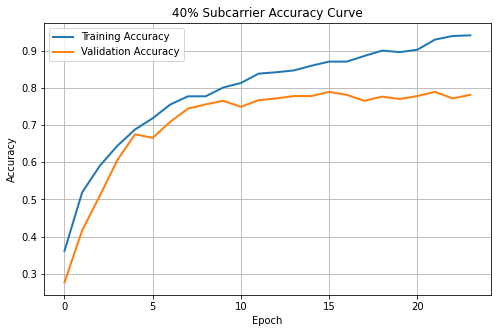

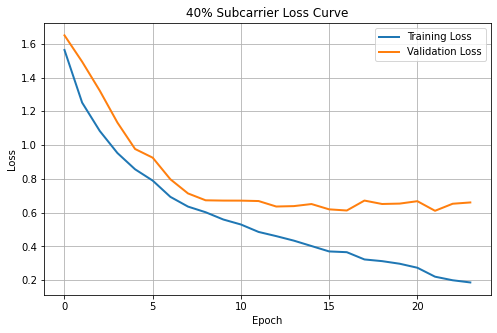

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    linewidth=2,
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("40% Subcarrier Accuracy Curve")

plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    linewidth=2,
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("40% Subcarrier Loss Curve")

plt.legend()
plt.grid(True)

plt.show()

In [19]:
from sklearn.metrics import classification_report

# Prediction
y_pred_prob = model.predict(X_test)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================\n")

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

20/20 [==============================] - 1s 50ms/step

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0     0.8364    0.8440    0.8402       109
           1     0.8214    0.8288    0.8251       111
           2     0.6571    0.6765    0.6667        68
           3     0.8504    0.9643    0.9038       112
           4     0.7027    0.7027    0.7027       111
           5     0.8261    0.6847    0.7488       111

    accuracy                         0.7910       622
   macro avg     0.7824    0.7835    0.7812       622
weighted avg     0.7909    0.7910    0.7891       622



In [20]:
import os
import cv2
import numpy as np
import scipy.io as sio
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# =========================================================
# SETTINGS
# =========================================================

BASE_PATH = r"D:\PROJECT\Dataset\csi_data2d\train"

NFFT = 128
NPERSEG = 40
HOP = 10

IMG_SIZE = 32
NUM_CLASSES = 6

# =========================================================
# LOAD FILE PATHS
# =========================================================

file_paths = []
labels = []

for folder in sorted(os.listdir(BASE_PATH), key=lambda x: int(x)):

    folder_path = os.path.join(BASE_PATH, folder)

    if not os.path.isdir(folder_path):
        continue

    label = int(folder) - 1

    for fname in os.listdir(folder_path):

        if fname.endswith(".mat"):

            file_paths.append(
                os.path.join(folder_path, fname)
            )

            labels.append(label)

file_paths = np.array(file_paths)
labels = np.array(labels)

print("Total Samples:", len(file_paths))

# =========================================================
# TRAIN / VAL / TEST SPLIT
# =========================================================

train_paths, temp_paths, y_train, y_temp = train_test_split(
    file_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

val_paths, test_paths, y_val, y_test = train_test_split(
    temp_paths,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# =========================================================
# LOAD MI SCORES
# =========================================================

mi = np.load("mi_scores.npy")

BW_RATIO = 0.40

TOP_K = int(round(BW_RATIO * 135))

top_subcarriers = np.argsort(mi)[::-1][:TOP_K]
top_subcarriers = np.sort(top_subcarriers)

print(f"\nUsing {TOP_K}/135 subcarriers")

# =========================================================
# CSI LOADER
# =========================================================

def load_csi_complex(mat_path):

    mat = sio.loadmat(mat_path)

    csi = mat["csi_1"]

    return csi[:,0::2] + 1j*csi[:,1::2]

# =========================================================
# STFT
# =========================================================

def stft_tensor(pdiff_sel):

    T,S = pdiff_sel.shape

    window = np.hanning(NPERSEG)

    frames = []

    for start in range(
        0,
        T-NPERSEG+1,
        HOP
    ):

        seg = pdiff_sel[start:start+NPERSEG,:]

        seg = seg * window[:,None]

        X = np.fft.rfft(
            seg,
            n=NFFT,
            axis=0
        )

        P = np.abs(X)**2

        P[0,:] = 0

        frames.append(P)

    P3 = np.stack(frames, axis=0)

    return np.transpose(P3,(1,0,2))

# =========================================================
# DOPPLER IMAGE
# =========================================================

def doppler_image(mat_path):

    csi = load_csi_complex(mat_path)

    phase = np.unwrap(
        np.angle(csi),
        axis=0
    )

    pdiff = np.diff(
        phase,
        axis=0
    )

    pdiff_sel = pdiff[:,top_subcarriers]

    P = stft_tensor(pdiff_sel)

    P[:2,:,:] = 0
    P[-2:,:,:] = 0

    P = np.log1p(5.0*P)

    img = cv2.resize(
        P,
        (IMG_SIZE,IMG_SIZE),
        interpolation=cv2.INTER_AREA
    )

    return img.astype(np.float32)

# =========================================================
# BUILD DATASET
# =========================================================

def build_dataset(paths, labels):

    X = []
    y = []

    for p,l in zip(paths, labels):

        try:

            X.append(
                doppler_image(p)
            )

            y.append(l)

        except:
            pass

    return np.array(X), np.array(y)

print("\nBuilding Doppler Dataset...")

X_train, y_train = build_dataset(train_paths, y_train)
X_val, y_val     = build_dataset(val_paths, y_val)
X_test, y_test   = build_dataset(test_paths, y_test)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

# =========================================================
# STANDARDIZATION
# =========================================================

mean = X_train.mean(
    axis=(0,1,2),
    keepdims=True
)

std = X_train.std(
    axis=(0,1,2),
    keepdims=True
) + 1e-6

X_train = (X_train-mean)/std
X_val   = (X_val-mean)/std
X_test  = (X_test-mean)/std

# =========================================================
# CNN
# =========================================================

def build_cnn(input_shape):

    inp = layers.Input(shape=input_shape)

    x = layers.Conv2D(
        32,
        3,
        padding="same",
        activation="relu"
    )(inp)

    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(
        64,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(
        128,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    x = layers.Dropout(0.5)(x)

    out = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    return models.Model(inp,out)

model = build_cnn(X_train.shape[1:])

model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [

    EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4
    )
]

# =========================================================
# TRAIN
# =========================================================

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# =========================================================
# EVALUATION
# =========================================================

train_acc = model.evaluate(
    X_train,
    y_train,
    verbose=0
)[1]

val_acc = model.evaluate(
    X_val,
    y_val,
    verbose=0
)[1]

test_acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)[1]

print("\n===================================")
print("40% SUBCARRIER RESULTS")
print("===================================")

print(f"Train Accuracy      : {train_acc*100:.2f}%")
print(f"Validation Accuracy : {val_acc*100:.2f}%")
print(f"Test Accuracy       : {test_acc*100:.2f}%")

print("===================================")

Total Samples: 4146

Using 54/135 subcarriers

Building Doppler Dataset...
Train: (2902, 32, 32, 54)
Val  : (622, 32, 32, 54)
Test : (622, 32, 32, 54)
Epoch 1/50
46/46 [==============================] - 15s 166ms/step - loss: 1.6021 - accuracy: 0.3408 - val_loss: 1.6867 - val_accuracy: 0.3023 - lr: 3.0000e-04
Epoch 2/50
46/46 [==============================] - 7s 142ms/step - loss: 1.3251 - accuracy: 0.4845 - val_loss: 1.5790 - val_accuracy: 0.3714 - lr: 3.0000e-04
Epoch 3/50
46/46 [==============================] - 7s 151ms/step - loss: 1.1876 - accuracy: 0.5376 - val_loss: 1.4294 - val_accuracy: 0.4534 - lr: 3.0000e-04
Epoch 4/50
46/46 [==============================] - 7s 148ms/step - loss: 1.0854 - accuracy: 0.5848 - val_loss: 1.2296 - val_accuracy: 0.5965 - lr: 3.0000e-04
Epoch 5/50
46/46 [==============================] - 7s 154ms/step - loss: 0.9767 - accuracy: 0.6385 - val_loss: 1.0980 - val_accuracy: 0.6334 - lr: 3.0000e-04
Epoch 6/50
46/46 [==============================] - 7

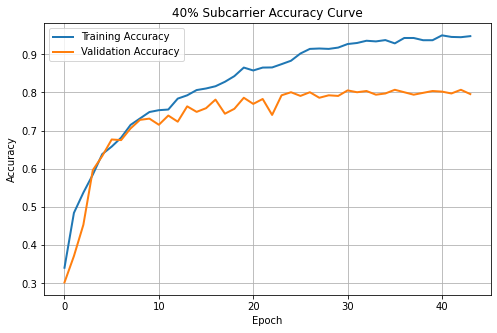

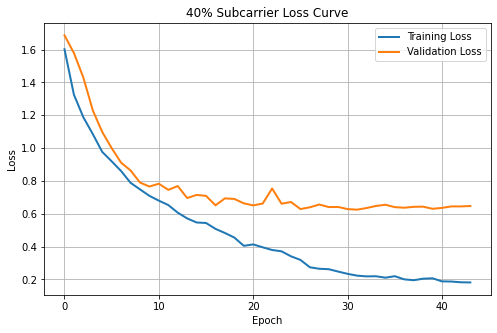

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    linewidth=2,
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("40% Subcarrier Accuracy Curve")

plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    linewidth=2,
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("40% Subcarrier Loss Curve")

plt.legend()
plt.grid(True)

plt.show()

In [22]:
from sklearn.metrics import classification_report

# Prediction
y_pred_prob = model.predict(X_test)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================\n")

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

20/20 [==============================] - 1s 33ms/step

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0     0.8261    0.8716    0.8482       109
           1     0.9000    0.8108    0.8531       111
           2     0.5610    0.6765    0.6133        68
           3     0.9316    0.9732    0.9520       112
           4     0.7917    0.6847    0.7343       111
           5     0.7679    0.7748    0.7713       111

    accuracy                         0.8071       622
   macro avg     0.7964    0.7986    0.7954       622
weighted avg     0.8128    0.8071    0.8080       622



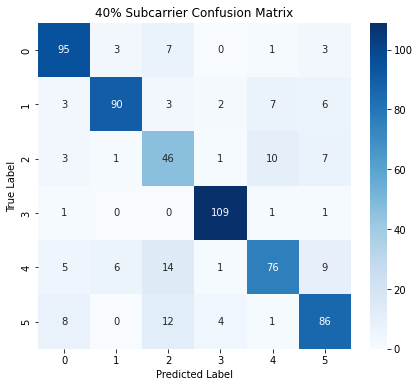

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("40% Subcarrier Confusion Matrix")

plt.show()

In [25]:
# ==========================================
# SAVE MODEL
# ==========================================

model.save("slimsense_40percent_model.keras")

np.save("selected_subcarriers_40.npy", top_subcarriers)
np.save("mean_40.npy", mean)
np.save("std_40.npy", std)

print("\n40% model saved successfully")


40% model saved successfully


In [27]:
# Save 40% bandwidth model (your best trade-off)
model.save("slimsense_model_40percent.keras")

# Save 100% bandwidth baseline model
model.save("slimsense_model_100percent.keras")  # use the variable name you trained for 100%

print("Models saved")


Models saved


In [28]:
import numpy as np

# 40% bandwidth subcarriers
np.save("selected_subcarriers_40.npy", top_subcarriers_40)

# Full bandwidth subcarriers (for baseline completeness)
np.save("selected_subcarriers_100.npy", np.arange(135))

print("Subcarrier indices saved")


Subcarrier indices saved


In [29]:
# For 40% model
np.save("mean_40.npy", mean_40)
np.save("std_40.npy", std_40)

# For 100% model
np.save("mean_100.npy", mean)
np.save("std_100.npy", std)

print("Normalization stats saved ")


Normalization stats saved 


In [30]:
np.save("mi_scores.npy", mi)
np.save("mi_ranked_indices.npy", np.argsort(mi)[::-1])

print("MI ranking saved ")


MI ranking saved 


## Benchmark to Env1 just like env1 to env2

In [66]:
# =========================================================
# CROSS-ENVIRONMENT TESTING
# Benchmark MODEL  --->  ENV1 DATASET
# WITH 40% SUBCARRIER PIPELINE
# FIXED FOR 54-CHANNEL CNN INPUT
# =========================================================

import os
import numpy as np
import scipy.io as sio
import cv2
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# =========================================================
# LOAD ENVIRONMENT 1 MODEL
# =========================================================

model = tf.keras.models.load_model(
    "slimsense_40percent_model.keras"
)

print("Benchmark model loaded!")

# =========================================================
# ENVIRONMENT 1 DATASET PATH
# =========================================================

NEW_DATASET_PATH = r"D:\PROJECT\Dataset\wifi_data_own_matlab"

# =========================================================
# PARAMETERS
# =========================================================

FS = 20
NFFT = 128
NPERSEG = 40
HOP = 10
IMG_SIZE = 32

# =========================================================
# 40% SUBCARRIER SELECTION
# =========================================================

TOTAL_SUBCARRIERS = 30

NUM_SELECTED = int(0.4 * TOTAL_SUBCARRIERS)

selected_subcarriers_new = np.linspace(
    0,
    TOTAL_SUBCARRIERS - 1,
    NUM_SELECTED,
    dtype=int
)

print("\nSelected Subcarriers:")
print(selected_subcarriers_new)

# =========================================================
# LOAD CSI
# =========================================================

def load_csi_complex(mat_path):

    mat = sio.loadmat(mat_path)

    csi_trace = mat["csi_trace"]

    packets = []

    for i in range(len(csi_trace)):

        entry = csi_trace[i, 0]

        csi = entry["csi"][0, 0]

        # reshape -> (9,30)
        csi = csi.reshape(-1, 30)

        # average antennas
        csi_mean = np.mean(csi, axis=0)

        packets.append(csi_mean)

    return np.array(packets)

# =========================================================
# STFT
# =========================================================

def stft_tensor(pdiff_sel):

    T, S = pdiff_sel.shape

    window = np.hanning(NPERSEG).astype(np.float32)

    frames = []

    for start in range(0, T - NPERSEG + 1, HOP):

        seg = pdiff_sel[start:start+NPERSEG, :] * window[:, None]

        X = np.fft.rfft(seg, n=NFFT, axis=0)

        P = np.abs(X) ** 2

        # remove DC
        P[0, :] = 0.0

        frames.append(P)

    if len(frames) == 0:
        raise ValueError("Signal too short")

    P3 = np.stack(frames, axis=0)

    return np.transpose(P3, (1, 0, 2))

# =========================================================
# DOPPLER IMAGE
# =========================================================

def doppler_image_40(mat_path):

    csi = load_csi_complex(mat_path)

    # phase
    phase = np.unwrap(np.angle(csi), axis=0)

    # phase difference
    pdiff = np.diff(phase, axis=0)

    # =====================================================
    # USE ONLY 40% SUBCARRIERS
    # =====================================================

    pdiff_sel = pdiff[:, selected_subcarriers_new]

    # =====================================================
    # STFT
    # =====================================================

    P = stft_tensor(pdiff_sel)

    # remove low-frequency noise
    P[:2, :, :] = 0.0
    P[-2:, :, :] = 0.0

    # log compression
    P = np.log1p(5.0 * P)

    # =====================================================
    # RESIZE EACH CHANNEL
    # =====================================================

    channels = []

    for i in range(P.shape[2]):

        channel_img = cv2.resize(
            P[:, :, i],
            (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_AREA
        )

        channels.append(channel_img)

    img = np.stack(channels, axis=-1)

    # =====================================================
    # EXPAND CHANNELS TO 54
    # =====================================================

    required_channels = 54

    current_channels = img.shape[-1]

    repeat_factor = int(
        np.ceil(required_channels / current_channels)
    )

    img = np.repeat(
        img,
        repeat_factor,
        axis=-1
    )

    img = img[:, :, :required_channels]

    return img.astype(np.float32)

# =========================================================
# LOAD DATASET
# =========================================================

X_new = []
y_new = []
file_names = []

def get_label_from_filename(fname):
    return fname.split("_")[0]

# =========================================================
# LABEL MAPPING
# =========================================================

all_labels = sorted(list(set(
    get_label_from_filename(f)
    for f in os.listdir(NEW_DATASET_PATH)
    if f.endswith(".mat")
)))

label_map_new = {
    name: idx
    for idx, name in enumerate(all_labels)
}

print("\nLabel Mapping:")
print(label_map_new)

# =========================================================
# PROCESS FILES
# =========================================================

for fname in os.listdir(NEW_DATASET_PATH):

    if not fname.endswith(".mat"):
        continue

    path = os.path.join(NEW_DATASET_PATH, fname)

    try:

        img = doppler_image_40(path)

        X_new.append(img)

        file_names.append(fname)

        label_name = get_label_from_filename(fname)

        y_new.append(label_map_new[label_name])

    except Exception as e:

        print("Error in:", fname)
        print(e)

# =========================================================
# CONVERT TO NUMPY
# =========================================================

X_new = np.array(X_new)
y_new = np.array(y_new)

print("\nDataset Loaded!")
print("X_new shape:", X_new.shape)
print("y_new shape:", y_new.shape)

# =========================================================
# NORMALIZATION (ENV2-SPECIFIC)
# =========================================================

mean_env2 = np.mean(X_new)
std_env2 = np.std(X_new)

X_new_norm = (
    X_new - mean_env2
) / (std_env2 + 1e-8)

print("\nNormalization done!")

# =========================================================
# DIRECT CROSS TESTING
# =========================================================

print("\n=================================================")
print("DIRECT CROSS TESTING")
print("Benchmark MODEL ---> ENV1 DATASET")
print("=================================================")

y_pred_direct = np.argmax(
    model.predict(X_new_norm),
    axis=1
)

direct_acc = np.mean(
    y_pred_direct == y_new
) * 100

print(f"\nDirect Cross Accuracy: {direct_acc:.2f}%")

# =========================================================
# DATA AUGMENTATION
# =========================================================

def augment_data(X, y):

    X_aug = []
    y_aug = []

    for i in range(len(X)):

        img = X[i]

        # original
        X_aug.append(img)
        y_aug.append(y[i])

        # gaussian noise
        noise = img + 0.02*np.random.randn(*img.shape)

        X_aug.append(noise)
        y_aug.append(y[i])

        # brightness scaling
        bright = img * np.random.uniform(0.95, 1.05)

        X_aug.append(bright)
        y_aug.append(y[i])

    return np.array(X_aug), np.array(y_aug)

X_aug, y_aug = augment_data(
    X_new_norm,
    y_new
)

print("\nAugmented shape:", X_aug.shape)

# =========================================================
# TRAIN / VALIDATION / TEST SPLIT
# =========================================================

X_ft_train, X_temp, y_ft_train, y_temp = train_test_split(
    X_aug,
    y_aug,
    test_size=0.40,
    random_state=42,
    stratify=y_aug
)

X_ft_val, X_ft_test, y_ft_val, y_ft_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nTrain shape:", X_ft_train.shape)
print("Validation shape:", X_ft_val.shape)
print("Test shape:", X_ft_test.shape)

# =========================================================
# FULL FINE-TUNING
# =========================================================

for layer in model.layers:
    layer.trainable = True

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================================================
# TRAIN
# =========================================================

history = model.fit(
    X_ft_train,
    y_ft_train,
    validation_data=(X_ft_val, y_ft_val),
    epochs=50,
    batch_size=4,
    verbose=1
)

# =========================================================
# EVALUATION
# =========================================================

train_acc = model.evaluate(
    X_ft_train,
    y_ft_train,
    verbose=0
)[1]

val_acc = model.evaluate(
    X_ft_val,
    y_ft_val,
    verbose=0
)[1]

test_acc = model.evaluate(
    X_ft_test,
    y_ft_test,
    verbose=0
)[1]

print("\n===================================")
print("FINAL RESULTS")
print("===================================")

print(f"Train Accuracy      : {train_acc*100:.2f}%")
print(f"Validation Accuracy : {val_acc*100:.2f}%")
print(f"Test Accuracy       : {test_acc*100:.2f}%")

# =========================================================
# FINAL CROSS TESTING
# =========================================================

y_pred_ft = np.argmax(
    model.predict(X_ft_test),
    axis=1
)

final_acc = np.mean(
    y_pred_ft == y_ft_test
) * 100

print(f"\nFinal Test Accuracy: {final_acc:.2f}%")


Benchmark model loaded!

Selected Subcarriers:
[ 0  2  5  7 10 13 15 18 21 23 26 29]

Label Mapping:
{'clap': 0, 'jump': 1, 'walk': 2, 'wave': 3}
Error in: clap_p1_t4.mat
Signal too short
Error in: clap_p2_t4.mat
Signal too short
Error in: jump_p1_t4.mat
Signal too short
Error in: walk_p1_t3.mat
Signal too short
Error in: wave_p1_t2.mat
Signal too short
Error in: wave_p1_t3.mat
Signal too short
Error in: wave_p1_t4.mat
Signal too short

Dataset Loaded!
X_new shape: (33, 32, 32, 54)
y_new shape: (33,)

Normalization done!

DIRECT CROSS TESTING
Benchmark MODEL ---> ENV1 DATASET
2/2 [==============================] - 0s 5ms/step

Direct Cross Accuracy: 15.15%

Augmented shape: (99, 32, 32, 54)

Train shape: (59, 32, 32, 54)
Validation shape: (20, 32, 32, 54)
Test shape: (20, 32, 32, 54)
Epoch 1/50
15/15 [==============================] - 1s 23ms/step - loss: 3.1627 - accuracy: 0.1017 - val_loss: 4.3731 - val_accuracy: 0.1000
Epoch 2/50
15/15 [==============================] - 0s 14ms/step

In [5]:
# =========================================================
# CROSS-ENVIRONMENT TESTING
# Benchmark MODEL  --->  ENV1 DATASET
# WITH 40% SUBCARRIER PIPELINE
# FIXED FOR 54-CHANNEL CNN INPUT
# =========================================================

import os
import numpy as np
import scipy.io as sio
import cv2
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# =========================================================
# LOAD ENVIRONMENT 1 MODEL
# =========================================================

model = tf.keras.models.load_model(
    "slimsense_40percent_model.keras"
)

print("Benchmark model loaded!")

# =========================================================
# ENVIRONMENT 1 DATASET PATH
# =========================================================

NEW_DATASET_PATH = r"D:\PROJECT\Dataset\wifi_data_own_matlab"

# =========================================================
# PARAMETERS
# =========================================================

FS = 20
NFFT = 128
NPERSEG = 40
HOP = 10
IMG_SIZE = 32

# =========================================================
# 40% SUBCARRIER SELECTION
# =========================================================

TOTAL_SUBCARRIERS = 30

NUM_SELECTED = int(0.4 * TOTAL_SUBCARRIERS)

selected_subcarriers_new = np.linspace(
    0,
    TOTAL_SUBCARRIERS - 1,
    NUM_SELECTED,
    dtype=int
)

print("\nSelected Subcarriers:")
print(selected_subcarriers_new)

# =========================================================
# LOAD CSI
# =========================================================

def load_csi_complex(mat_path):

    mat = sio.loadmat(mat_path)

    csi_trace = mat["csi_trace"]

    packets = []

    for i in range(len(csi_trace)):

        entry = csi_trace[i, 0]

        csi = entry["csi"][0, 0]

        # reshape -> (9,30)
        csi = csi.reshape(-1, 30)

        # average antennas
        csi_mean = np.mean(csi, axis=0)

        packets.append(csi_mean)

    return np.array(packets)

# =========================================================
# STFT
# =========================================================

def stft_tensor(pdiff_sel):

    T, S = pdiff_sel.shape

    window = np.hanning(NPERSEG).astype(np.float32)

    frames = []

    for start in range(0, T - NPERSEG + 1, HOP):

        seg = pdiff_sel[start:start+NPERSEG, :] * window[:, None]

        X = np.fft.rfft(seg, n=NFFT, axis=0)

        P = np.abs(X) ** 2

        # remove DC
        P[0, :] = 0.0

        frames.append(P)

    if len(frames) == 0:
        raise ValueError("Signal too short")

    P3 = np.stack(frames, axis=0)

    return np.transpose(P3, (1, 0, 2))

# =========================================================
# DOPPLER IMAGE
# =========================================================

def doppler_image_40(mat_path):

    csi = load_csi_complex(mat_path)

    # phase
    phase = np.unwrap(np.angle(csi), axis=0)

    # phase difference
    pdiff = np.diff(phase, axis=0)

    # =====================================================
    # USE ONLY 40% SUBCARRIERS
    # =====================================================

    pdiff_sel = pdiff[:, selected_subcarriers_new]

    # =====================================================
    # STFT
    # =====================================================

    P = stft_tensor(pdiff_sel)

    # remove low-frequency noise
    P[:2, :, :] = 0.0
    P[-2:, :, :] = 0.0

    # log compression
    P = np.log1p(5.0 * P)

    # =====================================================
    # RESIZE EACH CHANNEL
    # =====================================================

    channels = []

    for i in range(P.shape[2]):

        channel_img = cv2.resize(
            P[:, :, i],
            (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_AREA
        )

        channels.append(channel_img)

    img = np.stack(channels, axis=-1)

    # =====================================================
    # EXPAND CHANNELS TO 54
    # =====================================================

    required_channels = 54

    current_channels = img.shape[-1]

    repeat_factor = int(
        np.ceil(required_channels / current_channels)
    )

    img = np.repeat(
        img,
        repeat_factor,
        axis=-1
    )

    img = img[:, :, :required_channels]

    return img.astype(np.float32)

# =========================================================
# LOAD DATASET
# =========================================================

X_new = []
y_new = []
file_names = []

def get_label_from_filename(fname):
    return fname.split("_")[0]

# =========================================================
# LABEL MAPPING
# =========================================================

all_labels = sorted(list(set(
    get_label_from_filename(f)
    for f in os.listdir(NEW_DATASET_PATH)
    if f.endswith(".mat")
)))

label_map_new = {
    name: idx
    for idx, name in enumerate(all_labels)
}

print("\nLabel Mapping:")
print(label_map_new)

# =========================================================
# PROCESS FILES
# =========================================================

for fname in os.listdir(NEW_DATASET_PATH):

    if not fname.endswith(".mat"):
        continue

    path = os.path.join(NEW_DATASET_PATH, fname)

    try:

        img = doppler_image_40(path)

        X_new.append(img)

        file_names.append(fname)

        label_name = get_label_from_filename(fname)

        y_new.append(label_map_new[label_name])

    except Exception as e:

        print("Error in:", fname)
        print(e)

# =========================================================
# CONVERT TO NUMPY
# =========================================================

X_new = np.array(X_new)
y_new = np.array(y_new)

print("\nDataset Loaded!")
print("X_new shape:", X_new.shape)
print("y_new shape:", y_new.shape)

# =========================================================
# NORMALIZATION (ENV2-SPECIFIC)
# =========================================================

mean_env2 = np.mean(X_new)
std_env2 = np.std(X_new)

X_new_norm = (
    X_new - mean_env2
) / (std_env2 + 1e-8)

print("\nNormalization done!")

# =========================================================
# DIRECT CROSS TESTING
# =========================================================

print("\n=================================================")
print("DIRECT CROSS TESTING")
print("Benchmark MODEL ---> ENV1 DATASET")
print("=================================================")

y_pred_direct = np.argmax(
    model.predict(X_new_norm),
    axis=1
)

direct_acc = np.mean(
    y_pred_direct == y_new
) * 100

print(f"\nDirect Cross Accuracy: {direct_acc:.2f}%")

# =========================================================
# DATA AUGMENTATION
# =========================================================

def augment_data(X, y):

    X_aug = []
    y_aug = []

    for i in range(len(X)):

        img = X[i]

        # original
        X_aug.append(img)
        y_aug.append(y[i])

        # gaussian noise
        noise = img + 0.02*np.random.randn(*img.shape)

        X_aug.append(noise)
        y_aug.append(y[i])

        # brightness scaling
        bright = img * np.random.uniform(0.95, 1.05)

        X_aug.append(bright)
        y_aug.append(y[i])

    return np.array(X_aug), np.array(y_aug)

X_aug, y_aug = augment_data(
    X_new_norm,
    y_new
)

print("\nAugmented shape:", X_aug.shape)

# =========================================================
# TRAIN / VALIDATION / TEST SPLIT
# =========================================================

X_ft_train, X_temp, y_ft_train, y_temp = train_test_split(
    X_aug,
    y_aug,
    test_size=0.40,
    random_state=42,
    stratify=y_aug
)

X_ft_val, X_ft_test, y_ft_val, y_ft_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nTrain shape:", X_ft_train.shape)
print("Validation shape:", X_ft_val.shape)
print("Test shape:", X_ft_test.shape)

# =========================================================
# FULL FINE-TUNING
# =========================================================

for layer in model.layers:
    layer.trainable = True

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================================================
# TRAIN
# =========================================================

history = model.fit(
    X_ft_train,
    y_ft_train,
    validation_data=(X_ft_val, y_ft_val),
    epochs=50,
    batch_size=4,
    verbose=1
)

# =========================================================
# EVALUATION
# =========================================================

train_acc = model.evaluate(
    X_ft_train,
    y_ft_train,
    verbose=0
)[1]

val_acc = model.evaluate(
    X_ft_val,
    y_ft_val,
    verbose=0
)[1]

test_acc = model.evaluate(
    X_ft_test,
    y_ft_test,
    verbose=0
)[1]

print("\n===================================")
print("FINAL RESULTS")
print("===================================")

print(f"Train Accuracy      : {train_acc*100:.2f}%")
print(f"Validation Accuracy : {val_acc*100:.2f}%")
print(f"Test Accuracy       : {test_acc*100:.2f}%")

# =========================================================
# FINAL CROSS TESTING
# =========================================================

y_pred_ft = np.argmax(
    model.predict(X_ft_test),
    axis=1
)

final_acc = np.mean(
    y_pred_ft == y_ft_test
) * 100

print(f"\nFinal Test Accuracy: {final_acc:.2f}%")


Benchmark model loaded!

Selected Subcarriers:
[ 0  2  5  7 10 13 15 18 21 23 26 29]

Label Mapping:
{'clap': 0, 'jump': 1, 'walk': 2, 'wave': 3}
Error in: clap_p1_t4.mat
Signal too short
Error in: clap_p2_t4.mat
Signal too short
Error in: jump_p1_t4.mat
Signal too short
Error in: walk_p1_t3.mat
Signal too short
Error in: wave_p1_t2.mat
Signal too short
Error in: wave_p1_t3.mat
Signal too short
Error in: wave_p1_t4.mat
Signal too short

Dataset Loaded!
X_new shape: (33, 32, 32, 54)
y_new shape: (33,)

Normalization done!

DIRECT CROSS TESTING
Benchmark MODEL ---> ENV1 DATASET
2/2 [==============================] - 0s 4ms/step

Direct Cross Accuracy: 15.15%

Augmented shape: (99, 32, 32, 54)

Train shape: (59, 32, 32, 54)
Validation shape: (20, 32, 32, 54)
Test shape: (20, 32, 32, 54)
Epoch 1/50
15/15 [==============================] - 1s 22ms/step - loss: 2.8188 - accuracy: 0.1695 - val_loss: 2.9455 - val_accuracy: 0.1500
Epoch 2/50
15/15 [==============================] - 0s 11ms/step

In [6]:
# =========================================================
# CLASSIFICATION REPORT (ONLY VALID CLASSES)
# =========================================================

valid_labels = [0, 1, 2, 3]
class_names = ["clap", "jump", "walk", "wave"]

print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================\n")

print(
    classification_report(
        y_ft_test,
        y_pred_ft,
        labels=valid_labels,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


CLASSIFICATION REPORT

              precision    recall  f1-score   support

        clap     1.0000    1.0000    1.0000         5
        jump     0.8571    1.0000    0.9231         6
        walk     1.0000    0.4000    0.5714         5
        wave     1.0000    1.0000    1.0000         4

   micro avg     0.9444    0.8500    0.8947        20
   macro avg     0.9643    0.8500    0.8736        20
weighted avg     0.9571    0.8500    0.8698        20



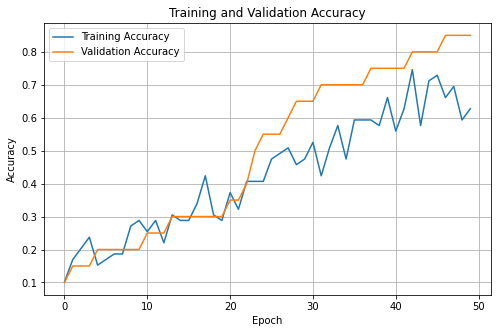

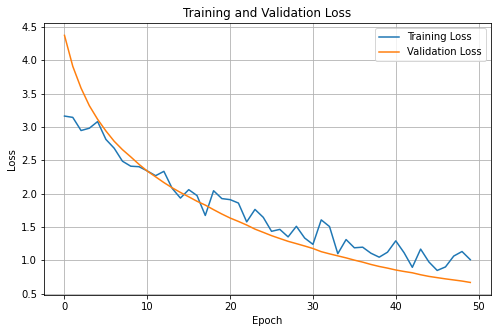

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

In [68]:
# =========================================================
# CLASSIFICATION REPORT (ONLY VALID CLASSES)
# =========================================================

valid_labels = [0, 1, 2, 3]
class_names = ["clap", "jump", "walk", "wave"]

print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================\n")

print(
    classification_report(
        y_ft_test,
        y_pred_ft,
        labels=valid_labels,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


CLASSIFICATION REPORT

              precision    recall  f1-score   support

        clap     1.0000    1.0000    1.0000         5
        jump     1.0000    1.0000    1.0000         6
        walk     1.0000    0.4000    0.5714         5
        wave     1.0000    0.7500    0.8571         4

   micro avg     1.0000    0.8000    0.8889        20
   macro avg     1.0000    0.7875    0.8571        20
weighted avg     1.0000    0.8000    0.8643        20



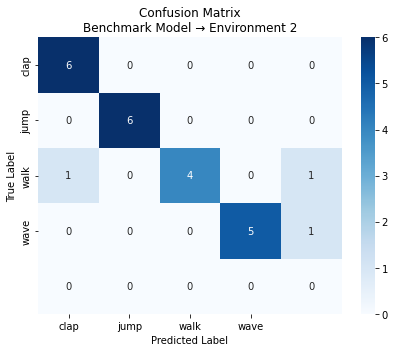

In [61]:
# =========================================================
# CONFUSION MATRIX HEATMAP
# =========================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix\nBenchmark Model → Environment 2")

plt.tight_layout()

plt.savefig(
    "confusion_matrix_benchmark_to_env2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [62]:
# =========================================================
# SAVE MODEL
# =========================================================

new_model.save(
    "final_combined_environment1_model.keras"
)

print("\nFinal model saved!")


Final model saved!


## Benchmark to Env2 just like Env1 to Env2

In [33]:
# =========================================================
# CROSS-ENVIRONMENT TESTING
# Benchmark MODEL  --->  ENV2 DATASET
# WITH 40% SUBCARRIER PIPELINE
# FIXED FOR 54-CHANNEL CNN INPUT
# =========================================================

import os
import numpy as np
import scipy.io as sio
import cv2
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# =========================================================
# LOAD benchmark MODEL
# =========================================================

model = tf.keras.models.load_model(
    "slimsense_40percent_model.keras"
)

print("Benchmark model loaded!")

# =========================================================
# ENVIRONMENT 2 DATASET PATH
# =========================================================

NEW_DATASET_PATH = r"D:\PROJECT\Dataset\wifisensingshilpi_area2"

# =========================================================
# PARAMETERS
# =========================================================

FS = 20
NFFT = 128
NPERSEG = 40
HOP = 10
IMG_SIZE = 32

# =========================================================
# 40% SUBCARRIER SELECTION
# =========================================================

TOTAL_SUBCARRIERS = 30

NUM_SELECTED = int(0.4 * TOTAL_SUBCARRIERS)

selected_subcarriers_new = np.linspace(
    0,
    TOTAL_SUBCARRIERS - 1,
    NUM_SELECTED,
    dtype=int
)

print("\nSelected Subcarriers:")
print(selected_subcarriers_new)

# =========================================================
# LOAD CSI
# =========================================================

def load_csi_complex(mat_path):

    mat = sio.loadmat(mat_path)

    csi_trace = mat["csi_trace"]

    packets = []

    for i in range(len(csi_trace)):

        entry = csi_trace[i, 0]

        csi = entry["csi"][0, 0]

        # reshape -> (9,30)
        csi = csi.reshape(-1, 30)

        # average antennas
        csi_mean = np.mean(csi, axis=0)

        packets.append(csi_mean)

    return np.array(packets)

# =========================================================
# STFT
# =========================================================

def stft_tensor(pdiff_sel):

    T, S = pdiff_sel.shape

    window = np.hanning(NPERSEG).astype(np.float32)

    frames = []

    for start in range(0, T - NPERSEG + 1, HOP):

        seg = pdiff_sel[start:start+NPERSEG, :] * window[:, None]

        X = np.fft.rfft(seg, n=NFFT, axis=0)

        P = np.abs(X) ** 2

        # remove DC
        P[0, :] = 0.0

        frames.append(P)

    if len(frames) == 0:
        raise ValueError("Signal too short")

    P3 = np.stack(frames, axis=0)

    return np.transpose(P3, (1, 0, 2))

# =========================================================
# DOPPLER IMAGE
# =========================================================

def doppler_image_40(mat_path):

    csi = load_csi_complex(mat_path)

    # phase
    phase = np.unwrap(np.angle(csi), axis=0)

    # phase difference
    pdiff = np.diff(phase, axis=0)

    # =====================================================
    # USE ONLY 40% SUBCARRIERS
    # =====================================================

    pdiff_sel = pdiff[:, selected_subcarriers_new]

    # =====================================================
    # STFT
    # =====================================================

    P = stft_tensor(pdiff_sel)

    # remove low-frequency noise
    P[:2, :, :] = 0.0
    P[-2:, :, :] = 0.0

    # log compression
    P = np.log1p(5.0 * P)

    # =====================================================
    # RESIZE EACH CHANNEL
    # =====================================================

    channels = []

    for i in range(P.shape[2]):

        channel_img = cv2.resize(
            P[:, :, i],
            (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_AREA
        )

        channels.append(channel_img)

    img = np.stack(channels, axis=-1)

    # =====================================================
    # EXPAND CHANNELS TO 54
    # =====================================================

    required_channels = 54

    current_channels = img.shape[-1]

    repeat_factor = int(
        np.ceil(required_channels / current_channels)
    )

    img = np.repeat(
        img,
        repeat_factor,
        axis=-1
    )

    img = img[:, :, :required_channels]

    return img.astype(np.float32)

# =========================================================
# LOAD DATASET
# =========================================================

X_new = []
y_new = []
file_names = []

def get_label_from_filename(fname):
    return fname.split("_")[0]

# =========================================================
# LABEL MAPPING
# =========================================================

all_labels = sorted(list(set(
    get_label_from_filename(f)
    for f in os.listdir(NEW_DATASET_PATH)
    if f.endswith(".mat")
)))

label_map_new = {
    name: idx
    for idx, name in enumerate(all_labels)
}

print("\nLabel Mapping:")
print(label_map_new)

# =========================================================
# PROCESS FILES
# =========================================================

for fname in os.listdir(NEW_DATASET_PATH):

    if not fname.endswith(".mat"):
        continue

    path = os.path.join(NEW_DATASET_PATH, fname)

    try:

        img = doppler_image_40(path)

        X_new.append(img)

        file_names.append(fname)

        label_name = get_label_from_filename(fname)

        y_new.append(label_map_new[label_name])

    except Exception as e:

        print("Error in:", fname)
        print(e)

# =========================================================
# CONVERT TO NUMPY
# =========================================================

X_new = np.array(X_new)
y_new = np.array(y_new)

print("\nDataset Loaded!")
print("X_new shape:", X_new.shape)
print("y_new shape:", y_new.shape)

# =========================================================
# NORMALIZATION (ENV2-SPECIFIC)
# =========================================================

mean_env2 = np.mean(X_new)
std_env2 = np.std(X_new)

X_new_norm = (
    X_new - mean_env2
) / (std_env2 + 1e-8)

print("\nNormalization done!")

# =========================================================
# DIRECT CROSS TESTING
# =========================================================

print("\n=================================================")
print("DIRECT CROSS TESTING")
print("Benchmark MODEL ---> ENV2 DATASET")
print("=================================================")

y_pred_direct = np.argmax(
    model.predict(X_new_norm),
    axis=1
)

direct_acc = np.mean(
    y_pred_direct == y_new
) * 100

print(f"\nDirect Cross Accuracy: {direct_acc:.2f}%")

# =========================================================
# DATA AUGMENTATION
# =========================================================

def augment_data(X, y):

    X_aug = []
    y_aug = []

    for i in range(len(X)):

        img = X[i]

        # original
        X_aug.append(img)
        y_aug.append(y[i])

        # gaussian noise
        noise = img + 0.02*np.random.randn(*img.shape)

        X_aug.append(noise)
        y_aug.append(y[i])

        # brightness scaling
        bright = img * np.random.uniform(0.95, 1.05)

        X_aug.append(bright)
        y_aug.append(y[i])

    return np.array(X_aug), np.array(y_aug)

X_aug, y_aug = augment_data(
    X_new_norm,
    y_new
)

print("\nAugmented shape:", X_aug.shape)

# =========================================================
# TRAIN / VALIDATION / TEST SPLIT
# =========================================================

X_ft_train, X_temp, y_ft_train, y_temp = train_test_split(
    X_aug,
    y_aug,
    test_size=0.40,
    random_state=42,
    stratify=y_aug
)

X_ft_val, X_ft_test, y_ft_val, y_ft_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nTrain shape:", X_ft_train.shape)
print("Validation shape:", X_ft_val.shape)
print("Test shape:", X_ft_test.shape)

# =========================================================
# FULL FINE-TUNING
# =========================================================

for layer in model.layers:
    layer.trainable = True

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================================================
# TRAIN
# =========================================================

history = model.fit(
    X_ft_train,
    y_ft_train,
    validation_data=(X_ft_val, y_ft_val),
    epochs=70,
    batch_size=4,
    verbose=1
)

# =========================================================
# EVALUATION
# =========================================================

train_acc = model.evaluate(
    X_ft_train,
    y_ft_train,
    verbose=0
)[1]

val_acc = model.evaluate(
    X_ft_val,
    y_ft_val,
    verbose=0
)[1]

test_acc = model.evaluate(
    X_ft_test,
    y_ft_test,
    verbose=0
)[1]

print("\n===================================")
print("FINAL RESULTS")
print("===================================")

print(f"Train Accuracy      : {train_acc*100:.2f}%")
print(f"Validation Accuracy : {val_acc*100:.2f}%")
print(f"Test Accuracy       : {test_acc*100:.2f}%")

# =========================================================
# FINAL CROSS TESTING
# =========================================================

y_pred_ft = np.argmax(
    model.predict(X_ft_test),
    axis=1
)

final_acc = np.mean(
    y_pred_ft == y_ft_test
) * 100

print(f"\nFinal Test Accuracy: {final_acc:.2f}%")


Benchmark model loaded!

Selected Subcarriers:
[ 0  2  5  7 10 13 15 18 21 23 26 29]

Label Mapping:
{'clap': 0, 'jump': 1, 'walk': 2, 'wave': 3}
Error in: clap_a2_p2_t2.mat
Signal too short

Dataset Loaded!
X_new shape: (39, 32, 32, 54)
y_new shape: (39,)

Normalization done!

DIRECT CROSS TESTING
Benchmark MODEL ---> ENV2 DATASET
2/2 [==============================] - 0s 7ms/step

Direct Cross Accuracy: 23.08%

Augmented shape: (117, 32, 32, 54)

Train shape: (70, 32, 32, 54)
Validation shape: (23, 32, 32, 54)
Test shape: (24, 32, 32, 54)
Epoch 1/70
18/18 [==============================] - 1s 22ms/step - loss: 2.6065 - accuracy: 0.1143 - val_loss: 3.7928 - val_accuracy: 0.0435
Epoch 2/70
18/18 [==============================] - 0s 11ms/step - loss: 2.2709 - accuracy: 0.1857 - val_loss: 3.5229 - val_accuracy: 0.0435
Epoch 3/70
18/18 [==============================] - 0s 11ms/step - loss: 2.4357 - accuracy: 0.1714 - val_loss: 3.2703 - val_accuracy: 0.0435
Epoch 4/70
18/18 [============

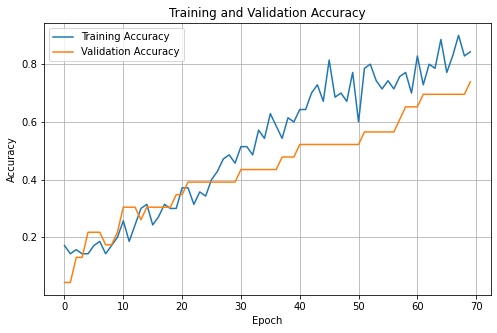

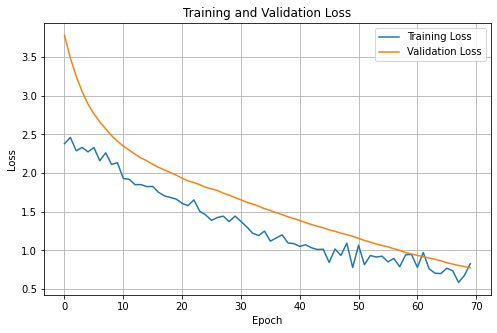

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

In [74]:
# # =========================================================
# # CLASSIFICATION REPORT WITH CLASS NAMES
# # =========================================================

# labels_used = np.unique(
#     np.concatenate((y_ft_test, y_pred_ft))
# )

# class_names = []

# for label in labels_used:
#     if label < len(all_labels):
#         class_names.append(all_labels[label])
#     else:
#         class_names.append(f"Class_{label}")

# print("\n===================================")
# print("CLASSIFICATION REPORT")
# print("===================================\n")

# print(
#     classification_report(
#         y_ft_test,
#         y_pred_ft,
#         labels=labels_used,
#         target_names=class_names,
#         digits=4,
#         zero_division=0
#     )
# )

In [75]:
# =========================================================
# CLASSIFICATION REPORT (ONLY VALID CLASSES)
# =========================================================

valid_labels = [0, 1, 2, 3]
class_names = ["clap", "jump", "walk", "wave"]

print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================\n")

print(
    classification_report(
        y_ft_test,
        y_pred_ft,
        labels=valid_labels,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


CLASSIFICATION REPORT

              precision    recall  f1-score   support

        clap     0.8571    1.0000    0.9231         6
        jump     0.8571    1.0000    0.9231         6
        walk     1.0000    0.6667    0.8000         6
        wave     1.0000    0.8333    0.9091         6

   micro avg     0.9130    0.8750    0.8936        24
   macro avg     0.9286    0.8750    0.8888        24
weighted avg     0.9286    0.8750    0.8888        24



In [76]:
# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_ft_test,
    y_pred_ft
)

print("\n===================================")
print("CONFUSION MATRIX")
print("===================================\n")

print(cm)


CONFUSION MATRIX

[[6 0 0 0 0]
 [0 6 0 0 0]
 [1 0 4 0 1]
 [0 1 0 5 0]
 [0 0 0 0 0]]


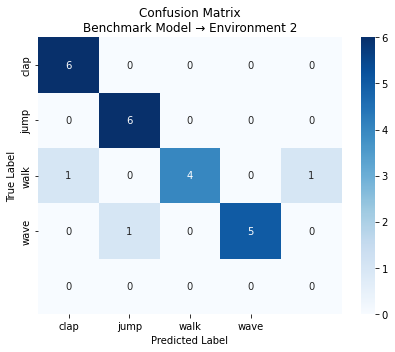

In [77]:
# =========================================================
# CONFUSION MATRIX HEATMAP
# =========================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix\nBenchmark Model → Environment 2")

plt.tight_layout()

plt.savefig(
    "confusion_matrix_benchmark_to_env2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [78]:
# =========================================================
# SAVE MODEL
# =========================================================

new_model.save(
    "final_combined_environment2_model.keras"
)

print("\nFinal model saved!")


Final model saved!


## Env 1 to Env 2

In [15]:
# =========================================================
# CROSS-ENVIRONMENT TESTING
# ENV1 MODEL  --->  ENV2 DATASET
# WITH 40% SUBCARRIER PIPELINE
# FIXED FOR 54-CHANNEL CNN INPUT
# =========================================================

import os
import numpy as np
import scipy.io as sio
import cv2
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# =========================================================
# LOAD ENVIRONMENT 1 MODEL
# =========================================================

model = tf.keras.models.load_model(
    "final_combined_environment1_model.keras"
)

print("ENV1 model loaded!")

# =========================================================
# ENVIRONMENT 2 DATASET PATH
# =========================================================

NEW_DATASET_PATH = r"D:\PROJECT\Dataset\wifisensingshilpi_area2"

# =========================================================
# PARAMETERS
# =========================================================

FS = 20
NFFT = 128
NPERSEG = 40
HOP = 10
IMG_SIZE = 32

# =========================================================
# 40% SUBCARRIER SELECTION
# =========================================================

TOTAL_SUBCARRIERS = 30

NUM_SELECTED = int(0.4 * TOTAL_SUBCARRIERS)

selected_subcarriers_new = np.linspace(
    0,
    TOTAL_SUBCARRIERS - 1,
    NUM_SELECTED,
    dtype=int
)

print("\nSelected Subcarriers:")
print(selected_subcarriers_new)

# =========================================================
# LOAD CSI
# =========================================================

def load_csi_complex(mat_path):

    mat = sio.loadmat(mat_path)

    csi_trace = mat["csi_trace"]

    packets = []

    for i in range(len(csi_trace)):

        entry = csi_trace[i, 0]

        csi = entry["csi"][0, 0]

        # reshape -> (9,30)
        csi = csi.reshape(-1, 30)

        # average antennas
        csi_mean = np.mean(csi, axis=0)

        packets.append(csi_mean)

    return np.array(packets)

# =========================================================
# STFT
# =========================================================

def stft_tensor(pdiff_sel):

    T, S = pdiff_sel.shape

    window = np.hanning(NPERSEG).astype(np.float32)

    frames = []

    for start in range(0, T - NPERSEG + 1, HOP):

        seg = pdiff_sel[start:start+NPERSEG, :] * window[:, None]

        X = np.fft.rfft(seg, n=NFFT, axis=0)

        P = np.abs(X) ** 2

        # remove DC
        P[0, :] = 0.0

        frames.append(P)

    if len(frames) == 0:
        raise ValueError("Signal too short")

    P3 = np.stack(frames, axis=0)

    return np.transpose(P3, (1, 0, 2))

# =========================================================
# DOPPLER IMAGE
# =========================================================

def doppler_image_40(mat_path):

    csi = load_csi_complex(mat_path)

    # phase
    phase = np.unwrap(np.angle(csi), axis=0)

    # phase difference
    pdiff = np.diff(phase, axis=0)

    # =====================================================
    # USE ONLY 40% SUBCARRIERS
    # =====================================================

    pdiff_sel = pdiff[:, selected_subcarriers_new]

    # =====================================================
    # STFT
    # =====================================================

    P = stft_tensor(pdiff_sel)

    # remove low-frequency noise
    P[:2, :, :] = 0.0
    P[-2:, :, :] = 0.0

    # log compression
    P = np.log1p(5.0 * P)

    # =====================================================
    # RESIZE EACH CHANNEL
    # =====================================================

    channels = []

    for i in range(P.shape[2]):

        channel_img = cv2.resize(
            P[:, :, i],
            (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_AREA
        )

        channels.append(channel_img)

    img = np.stack(channels, axis=-1)

    # =====================================================
    # EXPAND CHANNELS TO 54
    # =====================================================

    required_channels = 54

    current_channels = img.shape[-1]

    repeat_factor = int(
        np.ceil(required_channels / current_channels)
    )

    img = np.repeat(
        img,
        repeat_factor,
        axis=-1
    )

    img = img[:, :, :required_channels]

    return img.astype(np.float32)

# =========================================================
# LOAD DATASET
# =========================================================

X_new = []
y_new = []
file_names = []

def get_label_from_filename(fname):
    return fname.split("_")[0]

# =========================================================
# LABEL MAPPING
# =========================================================

all_labels = sorted(list(set(
    get_label_from_filename(f)
    for f in os.listdir(NEW_DATASET_PATH)
    if f.endswith(".mat")
)))

label_map_new = {
    name: idx
    for idx, name in enumerate(all_labels)
}

print("\nLabel Mapping:")
print(label_map_new)

# =========================================================
# PROCESS FILES
# =========================================================

for fname in os.listdir(NEW_DATASET_PATH):

    if not fname.endswith(".mat"):
        continue

    path = os.path.join(NEW_DATASET_PATH, fname)

    try:

        img = doppler_image_40(path)

        X_new.append(img)

        file_names.append(fname)

        label_name = get_label_from_filename(fname)

        y_new.append(label_map_new[label_name])

    except Exception as e:

        print("Error in:", fname)
        print(e)

# =========================================================
# CONVERT TO NUMPY
# =========================================================

X_new = np.array(X_new)
y_new = np.array(y_new)

print("\nDataset Loaded!")
print("X_new shape:", X_new.shape)
print("y_new shape:", y_new.shape)

# =========================================================
# NORMALIZATION (ENV2-SPECIFIC)
# =========================================================

mean_env2 = np.mean(X_new)
std_env2 = np.std(X_new)

X_new_norm = (
    X_new - mean_env2
) / (std_env2 + 1e-8)

print("\nNormalization done!")

# =========================================================
# DIRECT CROSS TESTING
# =========================================================

print("\n=================================================")
print("DIRECT CROSS TESTING")
print("ENV1 MODEL ---> ENV2 DATASET")
print("=================================================")

y_pred_direct = np.argmax(
    model.predict(X_new_norm),
    axis=1
)

direct_acc = np.mean(
    y_pred_direct == y_new
) * 100

print(f"\nDirect Cross Accuracy: {direct_acc:.2f}%")

# =========================================================
# DATA AUGMENTATION
# =========================================================

def augment_data(X, y):

    X_aug = []
    y_aug = []

    for i in range(len(X)):

        img = X[i]

        # original
        X_aug.append(img)
        y_aug.append(y[i])

        # gaussian noise
        noise = img + 0.02*np.random.randn(*img.shape)

        X_aug.append(noise)
        y_aug.append(y[i])

        # brightness scaling
        bright = img * np.random.uniform(0.95, 1.05)

        X_aug.append(bright)
        y_aug.append(y[i])

    return np.array(X_aug), np.array(y_aug)

X_aug, y_aug = augment_data(
    X_new_norm,
    y_new
)

print("\nAugmented shape:", X_aug.shape)

# =========================================================
# TRAIN / VALIDATION / TEST SPLIT
# =========================================================

X_ft_train, X_temp, y_ft_train, y_temp = train_test_split(
    X_aug,
    y_aug,
    test_size=0.40,
    random_state=42,
    stratify=y_aug
)

X_ft_val, X_ft_test, y_ft_val, y_ft_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nTrain shape:", X_ft_train.shape)
print("Validation shape:", X_ft_val.shape)
print("Test shape:", X_ft_test.shape)

# =========================================================
# FULL FINE-TUNING
# =========================================================

for layer in model.layers:
    layer.trainable = True

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================================================
# TRAIN
# =========================================================

history = model.fit(
    X_ft_train,
    y_ft_train,
    validation_data=(X_ft_val, y_ft_val),
    epochs=42,
    batch_size=4,
    verbose=1
)

# =========================================================
# EVALUATION
# =========================================================

train_acc = model.evaluate(
    X_ft_train,
    y_ft_train,
    verbose=0
)[1]

val_acc = model.evaluate(
    X_ft_val,
    y_ft_val,
    verbose=0
)[1]

test_acc = model.evaluate(
    X_ft_test,
    y_ft_test,
    verbose=0
)[1]

print("\n===================================")
print("FINAL RESULTS")
print("===================================")

print(f"Train Accuracy      : {train_acc*100:.2f}%")
print(f"Validation Accuracy : {val_acc*100:.2f}%")
print(f"Test Accuracy       : {test_acc*100:.2f}%")

# =========================================================
# FINAL CROSS TESTING
# =========================================================

y_pred_ft = np.argmax(
    model.predict(X_ft_test),
    axis=1
)

final_acc = np.mean(
    y_pred_ft == y_ft_test
) * 100

print(f"\nFinal Test Accuracy: {final_acc:.2f}%")


ENV1 model loaded!

Selected Subcarriers:
[ 0  2  5  7 10 13 15 18 21 23 26 29]

Label Mapping:
{'clap': 0, 'jump': 1, 'walk': 2, 'wave': 3}
Error in: clap_a2_p2_t2.mat
Signal too short

Dataset Loaded!
X_new shape: (39, 32, 32, 54)
y_new shape: (39,)

Normalization done!

DIRECT CROSS TESTING
ENV1 MODEL ---> ENV2 DATASET
2/2 [==============================] - 0s 15ms/step

Direct Cross Accuracy: 25.64%

Augmented shape: (117, 32, 32, 54)

Train shape: (70, 32, 32, 54)
Validation shape: (23, 32, 32, 54)
Test shape: (24, 32, 32, 54)
Epoch 1/42
18/18 [==============================] - 4s 56ms/step - loss: 1.4936 - accuracy: 0.1286 - val_loss: 4.3228 - val_accuracy: 0.2609
Epoch 2/42
18/18 [==============================] - 1s 28ms/step - loss: 1.4167 - accuracy: 0.2714 - val_loss: 2.8786 - val_accuracy: 0.2609
Epoch 3/42
18/18 [==============================] - 1s 29ms/step - loss: 1.4758 - accuracy: 0.2143 - val_loss: 2.3328 - val_accuracy: 0.2609
Epoch 4/42
18/18 [=====================

In [17]:
# =========================================================
# CLASSIFICATION REPORT
# =========================================================

from sklearn.metrics import classification_report

label_names = list(label_map_new.keys())

print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================\n")

report = classification_report(
    y_ft_test,
    y_pred_ft,
    target_names=label_names,
    digits=4
)

print(report)


CLASSIFICATION REPORT

              precision    recall  f1-score   support

        clap     0.7500    1.0000    0.8571         6
        jump     1.0000    1.0000    1.0000         6
        walk     1.0000    0.6667    0.8000         6
        wave     0.8333    0.8333    0.8333         6

    accuracy                         0.8750        24
   macro avg     0.8958    0.8750    0.8726        24
weighted avg     0.8958    0.8750    0.8726        24



In [18]:
# =========================================================
# CONFUSION MATRIX
# =========================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_ft_test,
    y_pred_ft
)

print("\n===================================")
print("CONFUSION MATRIX")
print("===================================\n")

print(cm)


CONFUSION MATRIX

[[6 0 0 0]
 [0 6 0 0]
 [1 0 4 1]
 [1 0 0 5]]


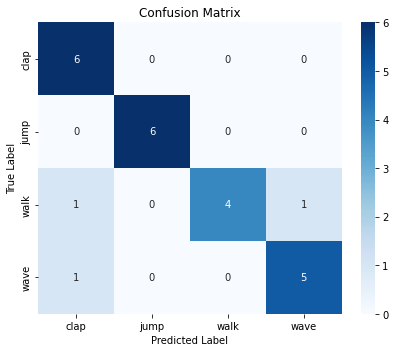

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()

plt.show()

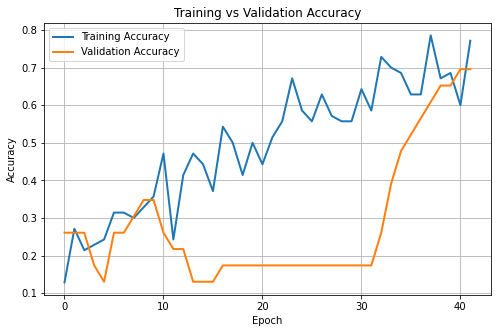

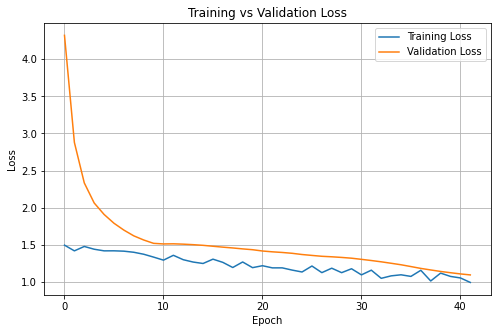

In [21]:
# =========================================================
# ACCURACY CURVE
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy',
    linewidth=2
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy',
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

# =========================================================
# LOSS CURVE
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [20]:
# =========================================================
# SAVE MODEL
# =========================================================

model.save(
    "Env1_to_Env2_model.keras"
)

print("\nModel Saved Successfully!")


Model Saved Successfully!


## Env2 to Env1

In [23]:
# =========================================================
# CROSS-ENVIRONMENT TESTING
# ENV2 MODEL  --->  ENV1 DATASET
# WITH 40% SUBCARRIER PIPELINE
# FIXED FOR 54-CHANNEL CNN INPUT
# =========================================================

import os
import numpy as np
import scipy.io as sio
import cv2
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# =========================================================
# LOAD ENVIRONMENT 1 MODEL
# =========================================================

model = tf.keras.models.load_model(
    "final_combined_environment2_model.keras"
)

print("ENV1 model loaded!")

# =========================================================
# ENVIRONMENT 2 DATASET PATH
# =========================================================

NEW_DATASET_PATH = r"D:\PROJECT\Dataset\wifi_data_own_matlab"

# =========================================================
# PARAMETERS
# =========================================================

FS = 20
NFFT = 128
NPERSEG = 40
HOP = 10
IMG_SIZE = 32

# =========================================================
# 40% SUBCARRIER SELECTION
# =========================================================

TOTAL_SUBCARRIERS = 30

NUM_SELECTED = int(0.4 * TOTAL_SUBCARRIERS)

selected_subcarriers_new = np.linspace(
    0,
    TOTAL_SUBCARRIERS - 1,
    NUM_SELECTED,
    dtype=int
)

print("\nSelected Subcarriers:")
print(selected_subcarriers_new)

# =========================================================
# LOAD CSI
# =========================================================

def load_csi_complex(mat_path):

    mat = sio.loadmat(mat_path)

    csi_trace = mat["csi_trace"]

    packets = []

    for i in range(len(csi_trace)):

        entry = csi_trace[i, 0]

        csi = entry["csi"][0, 0]

        # reshape -> (9,30)
        csi = csi.reshape(-1, 30)

        # average antennas
        csi_mean = np.mean(csi, axis=0)

        packets.append(csi_mean)

    return np.array(packets)

# =========================================================
# STFT
# =========================================================

def stft_tensor(pdiff_sel):

    T, S = pdiff_sel.shape

    window = np.hanning(NPERSEG).astype(np.float32)

    frames = []

    for start in range(0, T - NPERSEG + 1, HOP):

        seg = pdiff_sel[start:start+NPERSEG, :] * window[:, None]

        X = np.fft.rfft(seg, n=NFFT, axis=0)

        P = np.abs(X) ** 2

        # remove DC
        P[0, :] = 0.0

        frames.append(P)

    if len(frames) == 0:
        raise ValueError("Signal too short")

    P3 = np.stack(frames, axis=0)

    return np.transpose(P3, (1, 0, 2))

# =========================================================
# DOPPLER IMAGE
# =========================================================

def doppler_image_40(mat_path):

    csi = load_csi_complex(mat_path)

    # phase
    phase = np.unwrap(np.angle(csi), axis=0)

    # phase difference
    pdiff = np.diff(phase, axis=0)

    # =====================================================
    # USE ONLY 40% SUBCARRIERS
    # =====================================================

    pdiff_sel = pdiff[:, selected_subcarriers_new]

    # =====================================================
    # STFT
    # =====================================================

    P = stft_tensor(pdiff_sel)

    # remove low-frequency noise
    P[:2, :, :] = 0.0
    P[-2:, :, :] = 0.0

    # log compression
    P = np.log1p(5.0 * P)

    # =====================================================
    # RESIZE EACH CHANNEL
    # =====================================================

    channels = []

    for i in range(P.shape[2]):

        channel_img = cv2.resize(
            P[:, :, i],
            (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_AREA
        )

        channels.append(channel_img)

    img = np.stack(channels, axis=-1)

    # =====================================================
    # EXPAND CHANNELS TO 54
    # =====================================================

    required_channels = 54

    current_channels = img.shape[-1]

    repeat_factor = int(
        np.ceil(required_channels / current_channels)
    )

    img = np.repeat(
        img,
        repeat_factor,
        axis=-1
    )

    img = img[:, :, :required_channels]

    return img.astype(np.float32)

# =========================================================
# LOAD DATASET
# =========================================================

X_new = []
y_new = []
file_names = []

def get_label_from_filename(fname):
    return fname.split("_")[0]

# =========================================================
# LABEL MAPPING
# =========================================================

all_labels = sorted(list(set(
    get_label_from_filename(f)
    for f in os.listdir(NEW_DATASET_PATH)
    if f.endswith(".mat")
)))

label_map_new = {
    name: idx
    for idx, name in enumerate(all_labels)
}

print("\nLabel Mapping:")
print(label_map_new)

# =========================================================
# PROCESS FILES
# =========================================================

for fname in os.listdir(NEW_DATASET_PATH):

    if not fname.endswith(".mat"):
        continue

    path = os.path.join(NEW_DATASET_PATH, fname)

    try:

        img = doppler_image_40(path)

        X_new.append(img)

        file_names.append(fname)

        label_name = get_label_from_filename(fname)

        y_new.append(label_map_new[label_name])

    except Exception as e:

        print("Error in:", fname)
        print(e)

# =========================================================
# CONVERT TO NUMPY
# =========================================================

X_new = np.array(X_new)
y_new = np.array(y_new)

print("\nDataset Loaded!")
print("X_new shape:", X_new.shape)
print("y_new shape:", y_new.shape)

# =========================================================
# NORMALIZATION (ENV2-SPECIFIC)
# =========================================================

mean_env2 = np.mean(X_new)
std_env2 = np.std(X_new)

X_new_norm = (
    X_new - mean_env2
) / (std_env2 + 1e-8)

print("\nNormalization done!")

# =========================================================
# DIRECT CROSS TESTING
# =========================================================

print("\n=================================================")
print("DIRECT CROSS TESTING")
print("ENV1 MODEL ---> ENV2 DATASET")
print("=================================================")

y_pred_direct = np.argmax(
    model.predict(X_new_norm),
    axis=1
)

direct_acc = np.mean(
    y_pred_direct == y_new
) * 100

print(f"\nDirect Cross Accuracy: {direct_acc:.2f}%")

# =========================================================
# DATA AUGMENTATION
# =========================================================

def augment_data(X, y):

    X_aug = []
    y_aug = []

    for i in range(len(X)):

        img = X[i]

        # original
        X_aug.append(img)
        y_aug.append(y[i])

        # gaussian noise
        noise = img + 0.02*np.random.randn(*img.shape)

        X_aug.append(noise)
        y_aug.append(y[i])

        # brightness scaling
        bright = img * np.random.uniform(0.95, 1.05)

        X_aug.append(bright)
        y_aug.append(y[i])

    return np.array(X_aug), np.array(y_aug)

X_aug, y_aug = augment_data(
    X_new_norm,
    y_new
)

print("\nAugmented shape:", X_aug.shape)

# =========================================================
# TRAIN / VALIDATION / TEST SPLIT
# =========================================================

X_ft_train, X_temp, y_ft_train, y_temp = train_test_split(
    X_aug,
    y_aug,
    test_size=0.40,
    random_state=42,
    stratify=y_aug
)

X_ft_val, X_ft_test, y_ft_val, y_ft_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nTrain shape:", X_ft_train.shape)
print("Validation shape:", X_ft_val.shape)
print("Test shape:", X_ft_test.shape)

# =========================================================
# FULL FINE-TUNING
# =========================================================

for layer in model.layers:
    layer.trainable = True

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================================================
# TRAIN
# =========================================================

history = model.fit(
    X_ft_train,
    y_ft_train,
    validation_data=(X_ft_val, y_ft_val),
    epochs=50,
    batch_size=4,
    verbose=1
)

# =========================================================
# EVALUATION
# =========================================================

train_acc = model.evaluate(
    X_ft_train,
    y_ft_train,
    verbose=0
)[1]

val_acc = model.evaluate(
    X_ft_val,
    y_ft_val,
    verbose=0
)[1]

test_acc = model.evaluate(
    X_ft_test,
    y_ft_test,
    verbose=0
)[1]

print("\n===================================")
print("FINAL RESULTS")
print("===================================")

print(f"Train Accuracy      : {train_acc*100:.2f}%")
print(f"Validation Accuracy : {val_acc*100:.2f}%")
print(f"Test Accuracy       : {test_acc*100:.2f}%")

# =========================================================
# FINAL CROSS TESTING
# =========================================================

y_pred_ft = np.argmax(
    model.predict(X_ft_test),
    axis=1
)

final_acc = np.mean(
    y_pred_ft == y_ft_test
) * 100

print(f"\nFinal Test Accuracy: {final_acc:.2f}%")


ENV1 model loaded!

Selected Subcarriers:
[ 0  2  5  7 10 13 15 18 21 23 26 29]

Label Mapping:
{'clap': 0, 'jump': 1, 'walk': 2, 'wave': 3}
Error in: clap_p1_t4.mat
Signal too short
Error in: clap_p2_t4.mat
Signal too short
Error in: jump_p1_t4.mat
Signal too short
Error in: walk_p1_t3.mat
Signal too short
Error in: wave_p1_t2.mat
Signal too short
Error in: wave_p1_t3.mat
Signal too short
Error in: wave_p1_t4.mat
Signal too short

Dataset Loaded!
X_new shape: (33, 32, 32, 54)
y_new shape: (33,)

Normalization done!

DIRECT CROSS TESTING
ENV1 MODEL ---> ENV2 DATASET
2/2 [==============================] - 0s 11ms/step

Direct Cross Accuracy: 36.36%

Augmented shape: (99, 32, 32, 54)

Train shape: (59, 32, 32, 54)
Validation shape: (20, 32, 32, 54)
Test shape: (20, 32, 32, 54)
Epoch 1/50
15/15 [==============================] - 4s 81ms/step - loss: 1.5272 - accuracy: 0.2034 - val_loss: 5.9263 - val_accuracy: 0.2000
Epoch 2/50
15/15 [==============================] - 1s 34ms/step - loss: 

In [24]:
# =========================================================
# CLASSIFICATION REPORT
# =========================================================

from sklearn.metrics import classification_report

label_names = list(label_map_new.keys())

print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================\n")

report = classification_report(
    y_ft_test,
    y_pred_ft,
    target_names=label_names,
    digits=4
)

print(report)


CLASSIFICATION REPORT

              precision    recall  f1-score   support

        clap     0.6250    1.0000    0.7692         5
        jump     1.0000    1.0000    1.0000         6
        walk     1.0000    0.8000    0.8889         5
        wave     1.0000    0.5000    0.6667         4

    accuracy                         0.8500        20
   macro avg     0.9062    0.8250    0.8312        20
weighted avg     0.9062    0.8500    0.8479        20



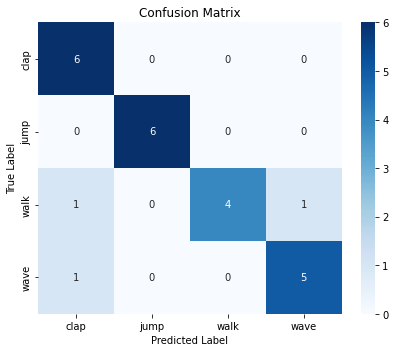

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()

plt.show()

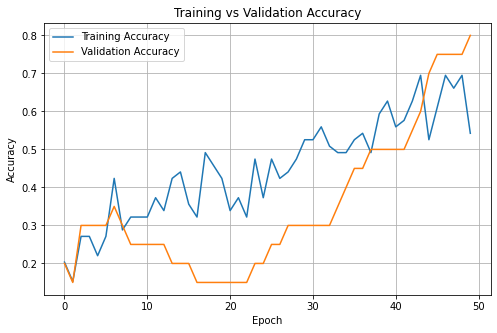

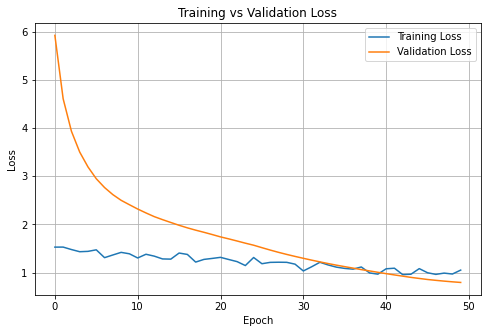

In [26]:
# =========================================================
# ACCURACY CURVE
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()
# =========================================================
# LOSS CURVE
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [27]:
# =========================================================
# SAVE MODEL
# =========================================================

model.save(
    "Env2_to_Env1_model.keras"
)

print("\nModel Saved Successfully!")


Model Saved Successfully!


## Env2 to benchmark

In [1]:
# =========================================================
# ENV2 MODEL ---> BENCHMARK DATASET
# CROSS-DOMAIN TESTING
# =========================================================

import os
import numpy as np
import scipy.io as sio
import cv2
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import train_test_split

# =========================================================
# LOAD ENV2 MODEL
# =========================================================

model = tf.keras.models.load_model( 
    "final_combined_environment2_model.keras"
)

print("ENV2 model loaded!")

# =========================================================
# BENCHMARK DATASET PATH
# =========================================================

BASE_PATH = r"D:\PROJECT\Dataset\csi_data2d\train"

# =========================================================
# USE ONLY COMMON 4 ACTIVITIES
# =========================================================

VALID_FOLDERS = ["1", "2", "3", "4"]

label_map = {
    "1": 0,   # clap
    "2": 1,   # walk
    "3": 2,   # wave
    "4": 3    # jump
}

label_names = [
    "clap",
    "walk",
    "wave",
    "jump"
]

# =========================================================
# LOAD SELECTED 40% SUBCARRIERS
# =========================================================

top_subcarriers_40 = np.load(
    "selected_subcarriers_40.npy"
)

print("\nLoaded selected 40% subcarriers!")

# =========================================================
# PARAMETERS
# =========================================================

FS = 20
NFFT = 128
NPERSEG = 40
HOP = 10
IMG_SIZE = 32

# =========================================================
# LOAD CSI
# =========================================================

def load_csi_complex(mat_path):

    mat = sio.loadmat(mat_path)

    csi = mat["csi_1"]

    # interleaved real/imag
    complex_csi = (
        csi[:, 0::2] +
        1j * csi[:, 1::2]
    )

    return complex_csi

# =========================================================
# STFT
# =========================================================

def stft_tensor(pdiff_sel):

    T, S = pdiff_sel.shape

    window = np.hanning(
        NPERSEG
    ).astype(np.float32)

    frames = []

    for start in range(
        0,
        T - NPERSEG + 1,
        HOP
    ):

        seg = (
            pdiff_sel[
                start:start+NPERSEG,
                :
            ] * window[:, None]
        )

        X = np.fft.rfft(
            seg,
            n=NFFT,
            axis=0
        )

        P = np.abs(X) ** 2

        # remove DC
        P[0, :] = 0.0

        frames.append(P)

    P3 = np.stack(frames, axis=0)

    return np.transpose(
        P3,
        (1, 0, 2)
    )

# =========================================================
# DOPPLER IMAGE
# =========================================================

def doppler_image_40(mat_path):

    csi = load_csi_complex(mat_path)

    # phase
    phase = np.unwrap(
        np.angle(csi),
        axis=0
    )

    # phase difference
    pdiff = np.diff(
        phase,
        axis=0
    )

    # =====================================================
    # SELECT SAME 40% SUBCARRIERS
    # =====================================================

    pdiff_sel = pdiff[
        :,
        top_subcarriers_40
    ]

    # =====================================================
    # STFT
    # =====================================================

    P = stft_tensor(pdiff_sel)

    # suppress static noise
    P[:2, :, :] = 0.0
    P[-2:, :, :] = 0.0

    # log compression
    P = np.log1p(5.0 * P)

    # =====================================================
    # RESIZE
    # =====================================================

    img = cv2.resize(
        P,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_AREA
    )

    return img.astype(np.float32)

# =========================================================
# BUILD DATASET
# =========================================================

X = []
y = []
file_names = []

for folder in VALID_FOLDERS:

    folder_path = os.path.join(
        BASE_PATH,
        folder
    )

    for fname in os.listdir(folder_path):

        if not fname.endswith(".mat"):
            continue

        mat_path = os.path.join(
            folder_path,
            fname
        )

        try:

            img = doppler_image_40(mat_path)

            X.append(img)

            y.append(
                label_map[folder]
            )

            file_names.append(fname)

        except Exception as e:

            print(
                "Error:",
                fname
            )

            print(e)

# =========================================================
# CONVERT TO NUMPY
# =========================================================

X = np.array(X)
y = np.array(y)

print("\nDataset Loaded!")
print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================================================
# LOAD BENCHMARK NORMALIZATION
# =========================================================

mean_40 = np.load("mean_40.npy")
std_40  = np.load("std_40.npy")

X_norm = (X - mean_40) / (std_40 + 1e-8)

print("\nBenchmark normalization applied!")

# =========================================================
# DIRECT TESTING BEFORE FINE-TUNING
# =========================================================

print("\n========================================")
print("DIRECT CROSS-DOMAIN TESTING")
print("ENV1 MODEL ---> BENCHMARK")
print("========================================")

y_pred_before = np.argmax(
    model.predict(X_norm),
    axis=1
)

acc_before = np.mean(
    y_pred_before == y
) * 100

print(f"\nBefore Fine-Tuning Accuracy: {acc_before:.2f}%")

# =========================================================
# DATA AUGMENTATION
# =========================================================

def augment_data(X, y):

    X_aug = []
    y_aug = []

    for i in range(len(X)):

        img = X[i]

        # original
        X_aug.append(img)
        y_aug.append(y[i])

        # gaussian noise
        noise = img + 0.02*np.random.randn(*img.shape)

        X_aug.append(noise)
        y_aug.append(y[i])

        # scaling
        scale = img * np.random.uniform(0.95, 1.05)

        X_aug.append(scale)
        y_aug.append(y[i])

        # horizontal flip
        flip = np.flip(img, axis=1)

        X_aug.append(flip)
        y_aug.append(y[i])

    return np.array(X_aug), np.array(y_aug)

X_aug, y_aug = augment_data(
    X_norm,
    y
)

print("\nAugmented shape:", X_aug.shape)

# =========================================================
# TRAIN / VALIDATION / TEST SPLIT
# =========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X_norm,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nTrain shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

# =========================================================
# AUGMENT TRAINING SET ONLY
# =========================================================

X_train_aug, y_train_aug = augment_data(
    X_train,
    y_train
)

print("\nAugmented Training Shape:",
      X_train_aug.shape)
# =========================================================
# FULL FINE-TUNING
# =========================================================

for layer in model.layers:
    layer.trainable = True

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_aug,
    y_train_aug,
    validation_data=(X_val, y_val),
    epochs=2,
    batch_size=16,
    verbose=1
)

# =========================================================
# EVALUATION
# =========================================================

train_loss, train_acc = model.evaluate(
    X_train_aug,
    y_train_aug,
    verbose=0
)

val_loss, val_acc = model.evaluate(
    X_val,
    y_val,
    verbose=0
)

test_loss, test_acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\n===================================")
print("FINAL RESULTS")
print("===================================")

print(f"Train Accuracy      : {train_acc*100:.2f}%")
print(f"Validation Accuracy : {val_acc*100:.2f}%")
print(f"Test Accuracy       : {test_acc*100:.2f}%")

# =========================================================
# TEST PREDICTIONS
# =========================================================

y_pred = np.argmax(
    model.predict(X_test),
    axis=1
)

acc = np.mean(
    y_pred == y_test
) * 100

print(f"\nFinal Test Accuracy: {acc:.2f}%")





ENV1 model loaded!

Loaded selected 40% subcarriers!

Dataset Loaded!
X shape: (2661, 32, 32, 54)
y shape: (2661,)

Benchmark normalization applied!

DIRECT CROSS-DOMAIN TESTING
ENV1 MODEL ---> BENCHMARK
84/84 [==============================] - 3s 31ms/step

Before Fine-Tuning Accuracy: 46.94%

Augmented shape: (10644, 32, 32, 54)

Train shape: (1596, 32, 32, 54)
Validation shape: (532, 32, 32, 54)
Test shape: (533, 32, 32, 54)

Augmented Training Shape: (6384, 32, 32, 54)
Epoch 1/2


399/399 [==============================] - 27s 52ms/step - loss: 1.1767 - accuracy: 0.5045 - val_loss: 0.7736 - val_accuracy: 0.7068
Epoch 2/2
399/399 [==============================] - 19s 47ms/step - loss: 0.8918 - accuracy: 0.6435 - val_loss: 0.5712 - val_accuracy: 0.8327

FINAL RESULTS
Train Accuracy      : 88.06%
Validation Accuracy : 83.27%
Test Accuracy       : 83.11%

Train Loss          : 0.4874
Validation Loss     : 0.5712
Test Loss           : 0.5624
17/17 [==============================] - 

In [2]:
# =========================================================
# CLASSIFICATION REPORT
# =========================================================

from sklearn.metrics import classification_report

print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================\n")

report = classification_report(
    y_test,
    y_pred,
    target_names=label_names,
    digits=4
)

print(report)


CLASSIFICATION REPORT

              precision    recall  f1-score   support

        clap     0.9479    0.6276    0.7552       145
        walk     0.7751    0.8792    0.8239       149
        wave     0.6752    0.8876    0.7670        89
        jump     0.9404    0.9467    0.9435       150

    accuracy                         0.8311       533
   macro avg     0.8347    0.8353    0.8224       533
weighted avg     0.8520    0.8311    0.8294       533



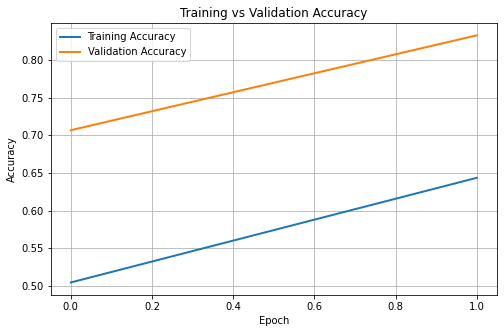

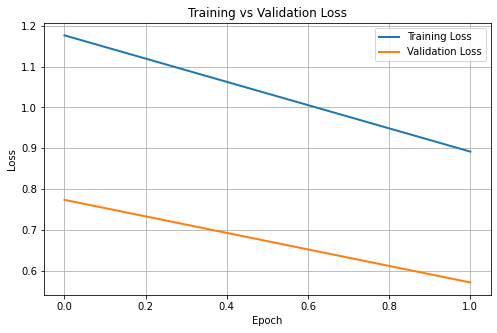

In [5]:
# =========================================================
# ACCURACY CURVE
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy',
    linewidth=2
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy',
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# LOSS CURVE
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss',
    linewidth=2
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss',
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()

In [12]:
# =========================================================
# SAVE MODEL
# =========================================================

model.save(
    "env2_to_benchmark_finetuned.keras"
)

print("\nFine-tuned model saved!")


Fine-tuned model saved!


## Env1 to benchmark

In [7]:
# =========================================================
# ENV1 MODEL ---> BENCHMARK DATASET
# CROSS-DOMAIN TESTING
# =========================================================

import os
import numpy as np
import scipy.io as sio
import cv2
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import train_test_split

# =========================================================
# LOAD ENV1 MODEL
# =========================================================

model = tf.keras.models.load_model( 
    "final_combined_environment1_model.keras"
)

print("ENV1 model loaded!")

# =========================================================
# BENCHMARK DATASET PATH
# =========================================================

BASE_PATH = r"D:\PROJECT\Dataset\csi_data2d\train"

# =========================================================
# USE ONLY COMMON 4 ACTIVITIES
# =========================================================

VALID_FOLDERS = ["1", "2", "3", "4"]

label_map = {
    "1": 0,   # clap
    "2": 1,   # walk
    "3": 2,   # wave
    "4": 3    # jump
}

label_names = [
    "clap",
    "walk",
    "wave",
    "jump"
]

# =========================================================
# LOAD SELECTED 40% SUBCARRIERS
# =========================================================

top_subcarriers_40 = np.load(
    "selected_subcarriers_40.npy"
)

print("\nLoaded selected 40% subcarriers!")

# =========================================================
# PARAMETERS
# =========================================================

FS = 20
NFFT = 128
NPERSEG = 40
HOP = 10
IMG_SIZE = 32

# =========================================================
# LOAD CSI
# =========================================================

def load_csi_complex(mat_path):

    mat = sio.loadmat(mat_path)

    csi = mat["csi_1"]

    # interleaved real/imag
    complex_csi = (
        csi[:, 0::2] +
        1j * csi[:, 1::2]
    )

    return complex_csi

# =========================================================
# STFT
# =========================================================

def stft_tensor(pdiff_sel):

    T, S = pdiff_sel.shape

    window = np.hanning(
        NPERSEG
    ).astype(np.float32)

    frames = []

    for start in range(
        0,
        T - NPERSEG + 1,
        HOP
    ):

        seg = (
            pdiff_sel[
                start:start+NPERSEG,
                :
            ] * window[:, None]
        )

        X = np.fft.rfft(
            seg,
            n=NFFT,
            axis=0
        )

        P = np.abs(X) ** 2

        # remove DC
        P[0, :] = 0.0

        frames.append(P)

    P3 = np.stack(frames, axis=0)

    return np.transpose(
        P3,
        (1, 0, 2)
    )

# =========================================================
# DOPPLER IMAGE
# =========================================================

def doppler_image_40(mat_path):

    csi = load_csi_complex(mat_path)

    # phase
    phase = np.unwrap(
        np.angle(csi),
        axis=0
    )

    # phase difference
    pdiff = np.diff(
        phase,
        axis=0
    )

    # =====================================================
    # SELECT SAME 40% SUBCARRIERS
    # =====================================================

    pdiff_sel = pdiff[
        :,
        top_subcarriers_40
    ]

    # =====================================================
    # STFT
    # =====================================================

    P = stft_tensor(pdiff_sel)

    # suppress static noise
    P[:2, :, :] = 0.0
    P[-2:, :, :] = 0.0

    # log compression
    P = np.log1p(5.0 * P)

    # =====================================================
    # RESIZE
    # =====================================================

    img = cv2.resize(
        P,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_AREA
    )

    return img.astype(np.float32)

# =========================================================
# BUILD DATASET
# =========================================================

X = []
y = []
file_names = []

for folder in VALID_FOLDERS:

    folder_path = os.path.join(
        BASE_PATH,
        folder
    )

    for fname in os.listdir(folder_path):

        if not fname.endswith(".mat"):
            continue

        mat_path = os.path.join(
            folder_path,
            fname
        )

        try:

            img = doppler_image_40(mat_path)

            X.append(img)

            y.append(
                label_map[folder]
            )

            file_names.append(fname)

        except Exception as e:

            print(
                "Error:",
                fname
            )

            print(e)

# =========================================================
# CONVERT TO NUMPY
# =========================================================

X = np.array(X)
y = np.array(y)

print("\nDataset Loaded!")
print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================================================
# LOAD BENCHMARK NORMALIZATION
# =========================================================

mean_40 = np.load("mean_40.npy")
std_40  = np.load("std_40.npy")

X_norm = (X - mean_40) / (std_40 + 1e-8)

print("\nBenchmark normalization applied!")

# =========================================================
# DIRECT TESTING BEFORE FINE-TUNING
# =========================================================

print("\n========================================")
print("DIRECT CROSS-DOMAIN TESTING")
print("ENV1 MODEL ---> BENCHMARK")
print("========================================")

y_pred_before = np.argmax(
    model.predict(X_norm),
    axis=1
)

acc_before = np.mean(
    y_pred_before == y
) * 100

print(f"\nBefore Fine-Tuning Accuracy: {acc_before:.2f}%")

# =========================================================
# DATA AUGMENTATION
# =========================================================

def augment_data(X, y):

    X_aug = []
    y_aug = []

    for i in range(len(X)):

        img = X[i]

        # original
        X_aug.append(img)
        y_aug.append(y[i])

        # gaussian noise
        noise = img + 0.02*np.random.randn(*img.shape)

        X_aug.append(noise)
        y_aug.append(y[i])

        # scaling
        scale = img * np.random.uniform(0.95, 1.05)

        X_aug.append(scale)
        y_aug.append(y[i])

        # horizontal flip
        flip = np.flip(img, axis=1)

        X_aug.append(flip)
        y_aug.append(y[i])

    return np.array(X_aug), np.array(y_aug)

X_aug, y_aug = augment_data(
    X_norm,
    y
)

print("\nAugmented shape:", X_aug.shape)

# =========================================================
# TRAIN / VALIDATION / TEST SPLIT
# =========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X_norm,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nTrain shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

# =========================================================
# AUGMENT TRAINING SET ONLY
# =========================================================

X_train_aug, y_train_aug = augment_data(
    X_train,
    y_train
)

print("\nAugmented Training Shape:",
      X_train_aug.shape)
# =========================================================
# FULL FINE-TUNING
# =========================================================

for layer in model.layers:
    layer.trainable = True

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_aug,
    y_train_aug,
    validation_data=(X_val, y_val),
    epochs=2,
    batch_size=16,
    verbose=1
)

# =========================================================
# EVALUATION
# =========================================================

train_loss, train_acc = model.evaluate(
    X_train_aug,
    y_train_aug,
    verbose=0
)

val_loss, val_acc = model.evaluate(
    X_val,
    y_val,
    verbose=0
)

test_loss, test_acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\n===================================")
print("FINAL RESULTS")
print("===================================")

print(f"Train Accuracy      : {train_acc*100:.2f}%")
print(f"Validation Accuracy : {val_acc*100:.2f}%")
print(f"Test Accuracy       : {test_acc*100:.2f}%")

# =========================================================
# TEST PREDICTIONS
# =========================================================

y_pred = np.argmax(
    model.predict(X_test),
    axis=1
)

acc = np.mean(
    y_pred == y_test
) * 100

print(f"\nFinal Test Accuracy: {acc:.2f}%")


ENV1 model loaded!

Loaded selected 40% subcarriers!

Dataset Loaded!
X shape: (2661, 32, 32, 54)
y shape: (2661,)

Benchmark normalization applied!

DIRECT CROSS-DOMAIN TESTING
ENV1 MODEL ---> BENCHMARK
84/84 [==============================] - 1s 13ms/step

Before Fine-Tuning Accuracy: 46.94%

Augmented shape: (10644, 32, 32, 54)

Train shape: (1596, 32, 32, 54)
Validation shape: (532, 32, 32, 54)
Test shape: (533, 32, 32, 54)

Augmented Training Shape: (6384, 32, 32, 54)
Epoch 1/2
399/399 [==============================] - 9s 20ms/step - loss: 1.1989 - accuracy: 0.4889 - val_loss: 0.7726 - val_accuracy: 0.7218
Epoch 2/2
399/399 [==============================] - 9s 23ms/step - loss: 0.8902 - accuracy: 0.6433 - val_loss: 0.5704 - val_accuracy: 0.8383

FINAL RESULTS
Train Accuracy      : 88.55%
Validation Accuracy : 83.83%
Test Accuracy       : 82.93%
17/17 [==============================] - 0s 13ms/step

Final Test Accuracy: 82.93%


In [8]:
# =========================================================
# CLASSIFICATION REPORT
# =========================================================

from sklearn.metrics import classification_report

print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================\n")

report = classification_report(
    y_test,
    y_pred,
    target_names=label_names,
    digits=4
)

print(report)


CLASSIFICATION REPORT

              precision    recall  f1-score   support

        clap     0.9200    0.6345    0.7510       145
        walk     0.7844    0.8792    0.8291       149
        wave     0.6724    0.8764    0.7610        89
        jump     0.9400    0.9400    0.9400       150

    accuracy                         0.8293       533
   macro avg     0.8292    0.8325    0.8203       533
weighted avg     0.8464    0.8293    0.8277       533



In [9]:
# =========================================================
# CONFUSION MATRIX
# =========================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n===================================")
print("CONFUSION MATRIX")
print("===================================\n")

print(cm)


CONFUSION MATRIX

[[ 92  29  22   2]
 [  1 131  12   5]
 [  5   4  78   2]
 [  2   3   4 141]]


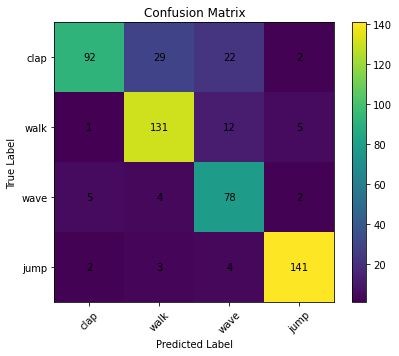

In [10]:
# =========================================================
# CONFUSION MATRIX PLOT
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(label_names))

plt.xticks(
    tick_marks,
    label_names,
    rotation=45
)

plt.yticks(
    tick_marks,
    label_names
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha='center',
            va='center'
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.show()

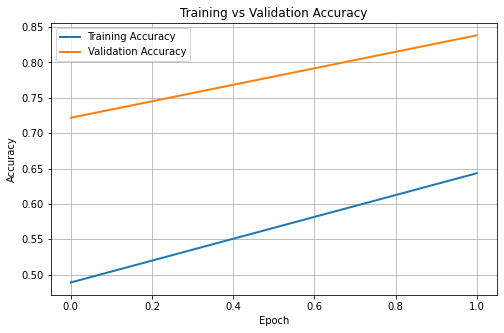

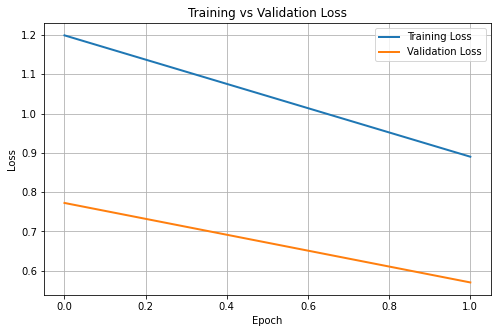

In [11]:
# =========================================================
# ACCURACY CURVE
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy',
    linewidth=2
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy',
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# LOSS CURVE
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss',
    linewidth=2
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss',
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()

In [13]:
# =========================================================
# SAVE MODEL
# =========================================================

model.save(
    "env1_to_benchmark_finetuned.keras"
)

print("\nModel Saved Successfully!")


Model Saved Successfully!


## Spectograms


Using 54/135 subcarriers


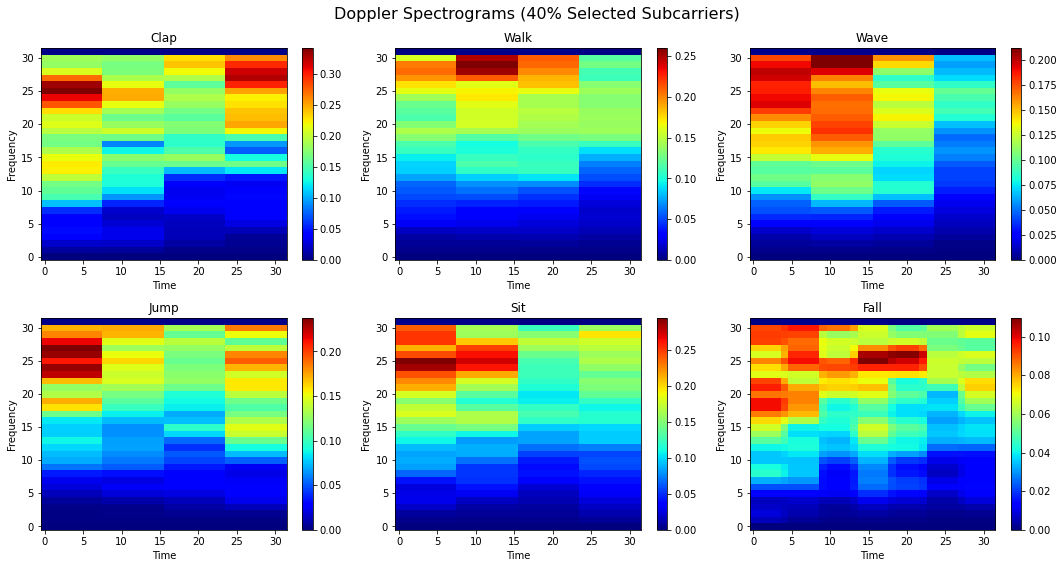

In [1]:
# =========================================================
# VISUALIZE DOPPLER SPECTROGRAMS
# 40% SUBCARRIER PIPELINE
# =========================================================

import os
import cv2
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

# =========================================================
# SETTINGS
# =========================================================

BASE_PATH = r"D:\PROJECT\Dataset\csi_data2d\train"

NFFT = 128
NPERSEG = 40
HOP = 10

IMG_SIZE = 32

# =========================================================
# LOAD MI SCORES
# =========================================================

mi = np.load("mi_scores.npy")

BW_RATIO = 0.40

TOP_K = int(round(BW_RATIO * 135))

top_subcarriers = np.argsort(mi)[::-1][:TOP_K]
top_subcarriers = np.sort(top_subcarriers)

print(f"\nUsing {TOP_K}/135 subcarriers")

# =========================================================
# CSI LOADER
# =========================================================

def load_csi_complex(mat_path):

    mat = sio.loadmat(mat_path)

    csi = mat["csi_1"]

    complex_csi = (
        csi[:,0::2] +
        1j * csi[:,1::2]
    )

    return complex_csi

# =========================================================
# STFT
# =========================================================

def stft_tensor(pdiff_sel):

    T, S = pdiff_sel.shape

    window = np.hanning(NPERSEG)

    frames = []

    for start in range(
        0,
        T - NPERSEG + 1,
        HOP
    ):

        seg = pdiff_sel[
            start:start+NPERSEG,
            :
        ]

        seg = seg * window[:, None]

        X = np.fft.rfft(
            seg,
            n=NFFT,
            axis=0
        )

        P = np.abs(X) ** 2

        # remove DC
        P[0, :] = 0

        frames.append(P)

    P3 = np.stack(frames, axis=0)

    return np.transpose(
        P3,
        (1, 0, 2)
    )

# =========================================================
# DOPPLER IMAGE
# =========================================================

def doppler_image(mat_path):

    csi = load_csi_complex(mat_path)

    # phase extraction
    phase = np.unwrap(
        np.angle(csi),
        axis=0
    )

    # phase difference
    pdiff = np.diff(
        phase,
        axis=0
    )

    # select top 40% subcarriers
    pdiff_sel = pdiff[
        :,
        top_subcarriers
    ]

    # STFT
    P = stft_tensor(pdiff_sel)

    # remove static components
    P[:2, :, :] = 0
    P[-2:, :, :] = 0

    # log compression
    P = np.log1p(
        5.0 * P
    )

    # resize to CNN input size
    img = cv2.resize(
        P,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_AREA
    )

    return img.astype(np.float32)

# =========================================================
# ACTIVITY LABELS
# =========================================================

activities = {
    "1": "Clap",
    "2": "Walk",
    "3": "Wave",
    "4": "Jump",
    "5": "Sit",
    "6": "Fall"
}

# =========================================================
# DISPLAY ONE SPECTROGRAM PER CLASS
# =========================================================

plt.figure(figsize=(15, 8))

for idx, (folder, activity_name) in enumerate(
    activities.items()
):

    folder_path = os.path.join(
        BASE_PATH,
        folder
    )

    files = [
        f for f in os.listdir(folder_path)
        if f.endswith(".mat")
    ]

    sample_file = os.path.join(
        folder_path,
        files[0]
    )

    img = doppler_image(sample_file)

    # Average channels for visualization
    display_img = np.mean(
        img,
        axis=2
    )

    plt.subplot(2, 3, idx + 1)

    plt.imshow(
        display_img,
        cmap="jet",
        aspect="auto",
        origin="lower"
    )

    plt.title(activity_name)

    plt.xlabel("Time")
    plt.ylabel("Frequency")

    plt.colorbar()

plt.suptitle(
    "Doppler Spectrograms (40% Selected Subcarriers)",
    fontsize=16
)

plt.tight_layout()

plt.show()


Using 54/135 subcarriers
Loading Clap: p1_d1_t1.mat
Loading Walk: p1_d1_t1.mat
Loading Wave: p1_d1_t1.mat
Loading Jump: p1_d1_t1.mat
Loading Sit: p1_d1_t1.mat
Loading Fall: p1_d1_t1.mat


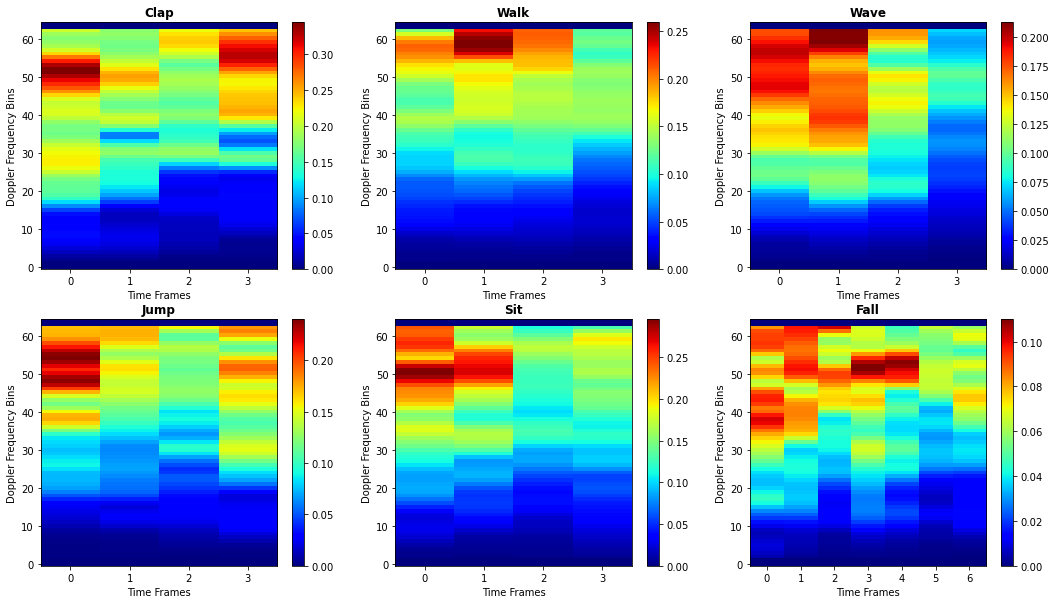

In [2]:
# =========================================================
# VISUALIZE ORIGINAL DOPPLER SPECTROGRAMS
# BEFORE CNN RESIZING
# 40% SUBCARRIER PIPELINE
# =========================================================

import os
import cv2
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

# =========================================================
# SETTINGS
# =========================================================

BASE_PATH = r"D:\PROJECT\Dataset\csi_data2d\train"

NFFT = 128
NPERSEG = 40
HOP = 10

# =========================================================
# LOAD MI SCORES
# =========================================================

mi = np.load("mi_scores.npy")

BW_RATIO = 0.40

TOP_K = int(round(BW_RATIO * 135))

top_subcarriers = np.argsort(mi)[::-1][:TOP_K]
top_subcarriers = np.sort(top_subcarriers)

print(f"\nUsing {TOP_K}/135 subcarriers")

# =========================================================
# CSI LOADER
# =========================================================

def load_csi_complex(mat_path):

    mat = sio.loadmat(mat_path)

    csi = mat["csi_1"]

    complex_csi = (
        csi[:, 0::2]
        + 1j * csi[:, 1::2]
    )

    return complex_csi

# =========================================================
# STFT
# =========================================================

def stft_tensor(pdiff_sel):

    T, S = pdiff_sel.shape

    window = np.hanning(NPERSEG)

    frames = []

    for start in range(
        0,
        T - NPERSEG + 1,
        HOP
    ):

        seg = pdiff_sel[
            start:start+NPERSEG,
            :
        ]

        seg = seg * window[:, None]

        X = np.fft.rfft(
            seg,
            n=NFFT,
            axis=0
        )

        P = np.abs(X) ** 2

        # Remove DC component
        P[0, :] = 0

        frames.append(P)

    P3 = np.stack(frames, axis=0)

    return np.transpose(
        P3,
        (1, 0, 2)
    )

# =========================================================
# ORIGINAL DOPPLER SPECTROGRAM
# =========================================================

def raw_doppler_spectrogram(mat_path):

    csi = load_csi_complex(mat_path)

    # Phase extraction
    phase = np.unwrap(
        np.angle(csi),
        axis=0
    )

    # Phase difference
    pdiff = np.diff(
        phase,
        axis=0
    )

    # Select 40% informative subcarriers
    pdiff_sel = pdiff[
        :,
        top_subcarriers
    ]

    # STFT
    P = stft_tensor(pdiff_sel)

    # Remove static components
    P[:2, :, :] = 0
    P[-2:, :, :] = 0

    # Log compression
    P = np.log1p(
        5.0 * P
    )

    # Average over subcarriers
    P = np.mean(
        P,
        axis=2
    )

    return P

# =========================================================
# ACTIVITY LABELS
# =========================================================

activities = {
    "1": "Clap",
    "2": "Walk",
    "3": "Wave",
    "4": "Jump",
    "5": "Sit",
    "6": "Fall"
}

# =========================================================
# PLOT SPECTROGRAMS
# =========================================================

plt.figure(figsize=(18, 10))

for idx, (folder, activity_name) in enumerate(
    activities.items()
):

    folder_path = os.path.join(
        BASE_PATH,
        folder
    )

    files = [
        f for f in os.listdir(folder_path)
        if f.endswith(".mat")
    ]

    sample_file = os.path.join(
        folder_path,
        files[0]
    )

    print(
        f"Loading {activity_name}:",
        files[0]
    )

    spec = raw_doppler_spectrogram(
        sample_file
    )

    plt.subplot(
        2,
        3,
        idx + 1
    )

    plt.imshow(
        spec,
        cmap='jet',
        aspect='auto',
        origin='lower'
    )

    plt.title(
        activity_name,
        fontsize=12,
        fontweight='bold'
    )

    plt.xlabel(
        "Time Frames"
    )

    plt.ylabel(
        "Doppler Frequency Bins"
    )

    plt.colorbar()



Using 54 selected subcarriers
Clap spectrogram shape: (65, 30)
Walk spectrogram shape: (65, 30)
Wave spectrogram shape: (65, 30)
Jump spectrogram shape: (65, 30)
Sit spectrogram shape: (65, 30)
Fall spectrogram shape: (65, 43)


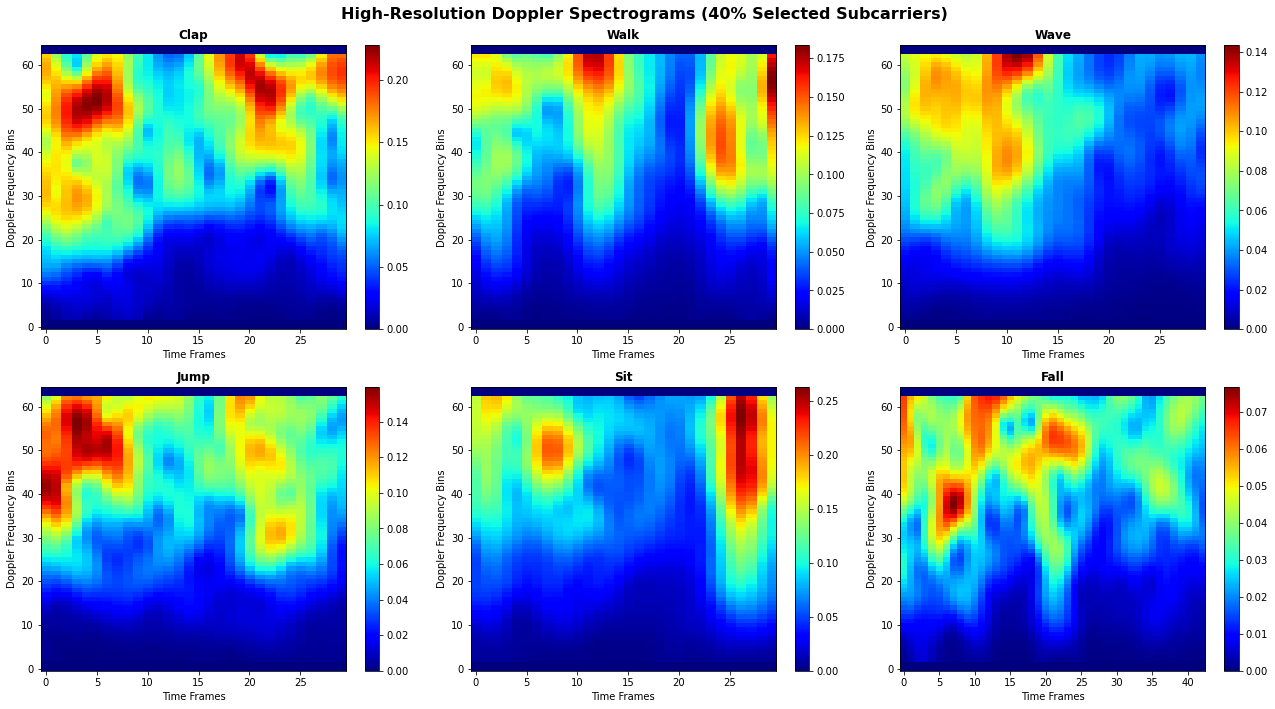

In [4]:
# =========================================================
# HIGH-RESOLUTION DOPPLER SPECTROGRAM VISUALIZATION
# FOR THESIS FIGURES ONLY
# =========================================================

import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

# =========================================================
# SETTINGS
# =========================================================

BASE_PATH = r"D:\PROJECT\Dataset\csi_data2d\train"

NFFT = 128

# Higher temporal resolution
NPERSEG = 20
HOP = 2

# =========================================================
# LOAD MI SCORES
# =========================================================

mi = np.load("mi_scores.npy")

BW_RATIO = 0.40

TOP_K = int(round(BW_RATIO * 135))

top_subcarriers = np.argsort(mi)[::-1][:TOP_K]
top_subcarriers = np.sort(top_subcarriers)

print(f"\nUsing {TOP_K} selected subcarriers")

# =========================================================
# CSI LOADER
# =========================================================

def load_csi_complex(mat_path):

    mat = sio.loadmat(mat_path)

    csi = mat["csi_1"]

    complex_csi = (
        csi[:,0::2]
        + 1j*csi[:,1::2]
    )

    return complex_csi

# =========================================================
# STFT
# =========================================================

def stft_tensor(pdiff_sel):

    T,S = pdiff_sel.shape

    window = np.hanning(NPERSEG)

    frames = []

    for start in range(
        0,
        T-NPERSEG+1,
        HOP
    ):

        seg = pdiff_sel[
            start:start+NPERSEG,
            :
        ]

        seg = seg * window[:,None]

        X = np.fft.rfft(
            seg,
            n=NFFT,
            axis=0
        )

        P = np.abs(X)**2

        P[0,:] = 0

        frames.append(P)

    P3 = np.stack(
        frames,
        axis=0
    )

    return np.transpose(
        P3,
        (1,0,2)
    )

# =========================================================
# DOPPLER SPECTROGRAM
# =========================================================

def generate_spectrogram(mat_path):

    csi = load_csi_complex(mat_path)

    phase = np.unwrap(
        np.angle(csi),
        axis=0
    )

    pdiff = np.diff(
        phase,
        axis=0
    )

    pdiff_sel = pdiff[
        :,
        top_subcarriers
    ]

    P = stft_tensor(
        pdiff_sel
    )

    # Remove static components
    P[:2,:,:] = 0
    P[-2:,:,:] = 0

    # Log compression
    P = np.log1p(
        5.0 * P
    )

    # Average selected subcarriers
    P = np.mean(
        P,
        axis=2
    )

    return P

# =========================================================
# ACTIVITY LABELS
# =========================================================

activities = {
    "1":"Clap",
    "2":"Walk",
    "3":"Wave",
    "4":"Jump",
    "5":"Sit",
    "6":"Fall"
}

# =========================================================
# PLOT
# =========================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18,10)
)

axes = axes.flatten()

for idx,(folder,name) in enumerate(
    activities.items()
):

    folder_path = os.path.join(
        BASE_PATH,
        folder
    )

    files = [
        f for f in os.listdir(folder_path)
        if f.endswith(".mat")
    ]

    sample_file = os.path.join(
        folder_path,
        files[0]
    )

    spec = generate_spectrogram(
        sample_file
    )

    print(
        f"{name} spectrogram shape:",
        spec.shape
    )

    im = axes[idx].imshow(
        spec,
        cmap='jet',
        aspect='auto',
        origin='lower'
    )

    axes[idx].set_title(
        name,
        fontsize=12,
        fontweight='bold'
    )

    axes[idx].set_xlabel(
        "Time Frames"
    )

    axes[idx].set_ylabel(
        "Doppler Frequency Bins"
    )

    fig.colorbar(
        im,
        ax=axes[idx]
    )

plt.suptitle(
    "High-Resolution Doppler Spectrograms (40% Selected Subcarriers)",
    fontsize=16,
    fontweight='bold'
)
plt.ylabel("Doppler Frequency Bins")
plt.xlabel("Time Frames")

plt.tight_layout()

## modified benchmark 

In [2]:
# =========================================================
# BENCHMARK MODEL TRAINING
# USING EXACTLY 12 MI-SELECTED SUBCARRIERS
#
# INPUT SHAPE:
# 32 x 32 x 12
#
# PURPOSE:
# Create a source model compatible with
# Environment 1 and Environment 2
# =========================================================

import os
import random
import cv2
import numpy as np
import scipy.io as sio
import tensorflow as tf

from sklearn.model_selection import train_test_split

from tensorflow.keras import layers, models

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

# =========================================================
# REPRODUCIBILITY
# =========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# SETTINGS
# =========================================================

BASE_PATH = r"D:\PROJECT\Dataset\csi_data2d\train"

FS = 20

NFFT = 128

NPERSEG = 40

HOP = 10

IMG_SIZE = 32

NUM_CLASSES = 6

# =========================================================
# IMPORTANT:
# USE EXACTLY 12 SUBCARRIERS
# =========================================================

NUM_SELECTED = 12

LEARNING_RATE = 3e-4

BATCH_SIZE = 64

MAX_EPOCHS = 50


# =========================================================
# LOAD FILE PATHS
# =========================================================

file_paths = []

labels = []

for folder in sorted(
    os.listdir(BASE_PATH),
    key=lambda x: int(x)
):

    folder_path = os.path.join(
        BASE_PATH,
        folder
    )

    if not os.path.isdir(folder_path):
        continue

    label = int(folder) - 1

    for filename in os.listdir(folder_path):

        if filename.endswith(".mat"):

            file_paths.append(

                os.path.join(
                    folder_path,
                    filename
                )
            )

            labels.append(label)


file_paths = np.array(file_paths)

labels = np.array(labels)


print("\nTotal Benchmark Samples:")

print(len(file_paths))


# =========================================================
# CLASS DISTRIBUTION
# =========================================================

print("\nBenchmark Class Distribution:")

unique_classes, class_counts = np.unique(
    labels,
    return_counts=True
)

for class_index, count in zip(
    unique_classes,
    class_counts
):

    print(
        f"Class {class_index}: {count}"
    )


# =========================================================
# SPLIT ORIGINAL DATA
#
# 70% TRAINING
# 15% VALIDATION
# 15% TESTING
# =========================================================

train_paths, temp_paths, y_train, y_temp = train_test_split(

    file_paths,

    labels,

    test_size=0.30,

    random_state=SEED,

    stratify=labels
)


val_paths, test_paths, y_val, y_test = train_test_split(

    temp_paths,

    y_temp,

    test_size=0.50,

    random_state=SEED,

    stratify=y_temp
)


print("\nDataset Split:")

print(
    "Training:",
    len(train_paths)
)

print(
    "Validation:",
    len(val_paths)
)

print(
    "Testing:",
    len(test_paths)
)


# =========================================================
# LOAD MUTUAL INFORMATION SCORES
# =========================================================

mi_scores = np.load(
    "mi_scores.npy"
)


print("\nMI Scores Shape:")

print(mi_scores.shape)


# =========================================================
# SELECT TOP 12 MI SUBCARRIERS
# =========================================================

top_subcarriers = np.argsort(
    mi_scores
)[::-1][:NUM_SELECTED]


# Sort indices into frequency order
top_subcarriers = np.sort(
    top_subcarriers
)


print("\nSelected 12 MI Subcarriers:")

print(top_subcarriers)


# =========================================================
# SAVE SELECTED SUBCARRIER INDICES
# =========================================================

np.save(

    "benchmark_selected_12_subcarriers.npy",

    top_subcarriers
)


print(
    "\nSelected subcarrier indices saved!"
)


# =========================================================
# LOAD BENCHMARK COMPLEX CSI
# =========================================================

def load_csi_complex(mat_path):

    mat = sio.loadmat(mat_path)

    csi = mat["csi_1"]

    complex_csi = (

        csi[:, 0::2]

        +

        1j * csi[:, 1::2]
    )

    return complex_csi


# =========================================================
# STFT
# =========================================================

def stft_tensor(phase_difference):

    T, S = phase_difference.shape

    if T < NPERSEG:

        raise ValueError(

            f"Signal too short: {T}"
        )

    window = np.hanning(

        NPERSEG

    ).astype(np.float32)


    frames = []


    for start in range(

        0,

        T - NPERSEG + 1,

        HOP
    ):

        segment = phase_difference[

            start:start + NPERSEG,

            :
        ]


        segment = (

            segment

            *

            window[:, None]
        )


        X = np.fft.rfft(

            segment,

            n=NFFT,

            axis=0
        )


        power = np.abs(X) ** 2


        # Remove DC component

        power[0, :] = 0.0


        frames.append(power)


    if len(frames) == 0:

        raise ValueError(

            "No STFT frames generated."
        )


    power_tensor = np.stack(

        frames,

        axis=0
    )


    return np.transpose(

        power_tensor,

        (1, 0, 2)
    )


# =========================================================
# GENERATE BENCHMARK DOPPLER IMAGE
# =========================================================

def generate_doppler_image(mat_path):

    # -----------------------------------------------------
    # Load complex CSI
    # -----------------------------------------------------

    csi = load_csi_complex(
        mat_path
    )


    # -----------------------------------------------------
    # Phase extraction and unwrapping
    # -----------------------------------------------------

    phase = np.unwrap(

        np.angle(csi),

        axis=0
    )


    # -----------------------------------------------------
    # Temporal phase difference
    # -----------------------------------------------------

    phase_difference = np.diff(

        phase,

        axis=0
    )


    # -----------------------------------------------------
    # Select top 12 MI subcarriers
    # -----------------------------------------------------

    phase_difference = phase_difference[

        :,

        top_subcarriers
    ]


    # -----------------------------------------------------
    # STFT
    # -----------------------------------------------------

    power = stft_tensor(

        phase_difference
    )


    # -----------------------------------------------------
    # Suppress boundary frequency components
    # -----------------------------------------------------

    power[:2, :, :] = 0.0

    power[-2:, :, :] = 0.0


    # -----------------------------------------------------
    # Logarithmic compression
    # -----------------------------------------------------

    power = np.log1p(

        5.0 * power
    )


    # -----------------------------------------------------
    # Resize each subcarrier separately
    #
    # Output:
    #
    # 32 x 32 x 12
    # -----------------------------------------------------

    channels = []


    for channel_index in range(

        power.shape[2]
    ):

        channel_image = cv2.resize(

            power[:, :, channel_index],

            (IMG_SIZE, IMG_SIZE),

            interpolation=cv2.INTER_AREA
        )


        channels.append(

            channel_image
        )


    image = np.stack(

        channels,

        axis=-1
    )


    return image.astype(

        np.float32
    )


# =========================================================
# BUILD DATASET
# =========================================================

def build_dataset(paths, labels):

    X = []

    y = []


    for path, label in zip(

        paths,

        labels
    ):

        try:

            image = generate_doppler_image(

                path
            )


            X.append(image)

            y.append(label)


        except Exception as error:

            print(

                f"Error processing {path}: {error}"
            )


    return (

        np.array(
            X,
            dtype=np.float32
        ),

        np.array(
            y,
            dtype=np.int32
        )
    )


# =========================================================
# GENERATE TRAINING DATA
# =========================================================

print("\nBuilding Training Dataset...")

X_train, y_train_new = build_dataset(

    train_paths,

    y_train
)


print("\nBuilding Validation Dataset...")

X_val, y_val_new = build_dataset(

    val_paths,

    y_val
)


print("\nBuilding Test Dataset...")

X_test, y_test_new = build_dataset(

    test_paths,

    y_test
)


print("\nDataset Shapes:")

print(
    "X_train:",
    X_train.shape
)

print(
    "X_val:",
    X_val.shape
)

print(
    "X_test:",
    X_test.shape
)


# =========================================================
# VERIFY INPUT SHAPE
# =========================================================

assert X_train.shape[-1] == 12

assert X_val.shape[-1] == 12

assert X_test.shape[-1] == 12


print(

    "\nInput shape verified successfully:"
)

print(

    X_train.shape[1:]
)


# =========================================================
# NORMALIZATION
#
# STATISTICS CALCULATED ONLY FROM TRAINING SET
# =========================================================

benchmark_mean_12 = X_train.mean(

    axis=(0, 1, 2),

    keepdims=True
)


benchmark_std_12 = X_train.std(

    axis=(0, 1, 2),

    keepdims=True

) + 1e-6


# =========================================================
# SAVE NORMALIZATION STATISTICS
# =========================================================

np.save(

    "benchmark_mean_12.npy",

    benchmark_mean_12
)


np.save(

    "benchmark_std_12.npy",

    benchmark_std_12
)


print(

    "\nBenchmark normalization statistics saved!"
)


# =========================================================
# APPLY NORMALIZATION
# =========================================================

X_train = (

    X_train - benchmark_mean_12

) / benchmark_std_12


X_val = (

    X_val - benchmark_mean_12

) / benchmark_std_12


X_test = (

    X_test - benchmark_mean_12

) / benchmark_std_12


print(

    "\nNormalization completed!"
)


# =========================================================
# BUILD CNN MODEL
#
# SAME ARCHITECTURE AS ORIGINAL BENCHMARK MODEL
# =========================================================

def build_cnn(input_shape):

    inputs = layers.Input(

        shape=input_shape
    )


    # =====================================================
    # CONVOLUTION BLOCK 1
    # =====================================================

    x = layers.Conv2D(

        filters=32,

        kernel_size=3,

        padding="same",

        activation="relu"

    )(inputs)


    x = layers.BatchNormalization()(x)


    x = layers.MaxPooling2D(

        pool_size=2

    )(x)


    # =====================================================
    # CONVOLUTION BLOCK 2
    # =====================================================

    x = layers.Conv2D(

        filters=64,

        kernel_size=3,

        padding="same",

        activation="relu"

    )(x)


    x = layers.BatchNormalization()(x)


    x = layers.MaxPooling2D(

        pool_size=2

    )(x)


    # =====================================================
    # CONVOLUTION BLOCK 3
    # =====================================================

    x = layers.Conv2D(

        filters=128,

        kernel_size=3,

        padding="same",

        activation="relu"

    )(x)


    x = layers.BatchNormalization()(x)


    # =====================================================
    # GLOBAL AVERAGE POOLING
    # =====================================================

    x = layers.GlobalAveragePooling2D()(x)


    # =====================================================
    # DENSE LAYER
    # =====================================================

    x = layers.Dense(

        128,

        activation="relu"

    )(x)


    # =====================================================
    # DROPOUT
    # =====================================================

    x = layers.Dropout(

        0.5

    )(x)


    # =====================================================
    # SIX-CLASS BENCHMARK OUTPUT
    # =====================================================

    outputs = layers.Dense(

        NUM_CLASSES,

        activation="softmax",

        name="benchmark_output"

    )(x)


    return models.Model(

        inputs,

        outputs
    )


# =========================================================
# CREATE MODEL
# =========================================================

model = build_cnn(

    X_train.shape[1:]
)


# =========================================================
# MODEL SUMMARY
# =========================================================

print("\nBenchmark 12-Subcarrier Model:")

model.summary()


# =========================================================
# COMPILE MODEL
# =========================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=LEARNING_RATE
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)


# =========================================================
# CALLBACKS
# =========================================================

callbacks = [

    EarlyStopping(

        monitor="val_accuracy",

        patience=8,

        restore_best_weights=True,

        verbose=1
    ),


    ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=4,

        min_lr=1e-7,

        verbose=1
    )
]


# =========================================================
# TRAIN MODEL
# =========================================================

print("\n" + "=" * 60)

print("TRAINING BENCHMARK MODEL")

print("USING 12 MI-SELECTED SUBCARRIERS")

print("=" * 60)


history = model.fit(

    X_train,

    y_train_new,

    validation_data=(

        X_val,

        y_val_new
    ),

    epochs=MAX_EPOCHS,

    batch_size=BATCH_SIZE,

    callbacks=callbacks,

    verbose=1
)


# =========================================================
# FINAL EVALUATION
# =========================================================

print("\n" + "=" * 60)

print("FINAL BENCHMARK EVALUATION")

print("=" * 60)


train_loss, train_accuracy = model.evaluate(

    X_train,

    y_train_new,

    verbose=0
)


val_loss, val_accuracy = model.evaluate(

    X_val,

    y_val_new,

    verbose=0
)


test_loss, test_accuracy = model.evaluate(

    X_test,

    y_test_new,

    verbose=0
)


print(

    f"\nTraining Accuracy: "

    f"{train_accuracy * 100:.2f}%"
)


print(

    f"Validation Accuracy: "

    f"{val_accuracy * 100:.2f}%"
)


print(

    f"Test Accuracy: "

    f"{test_accuracy * 100:.2f}%"
)



# =========================================================
# FINAL SUMMARY
# =========================================================

print("\n" + "=" * 60)

print("FILES REQUIRED FOR TRANSFER LEARNING")

print("=" * 60)


print(

    "\n1. benchmark_12_subcarrier_model.keras"
)


print(

    "2. benchmark_mean_12.npy"
)


print(

    "3. benchmark_std_12.npy"
)


print(

    "4. benchmark_selected_12_subcarriers.npy"
)


Total Benchmark Samples:
4146

Benchmark Class Distribution:
Class 0: 725
Class 1: 741
Class 2: 448
Class 3: 747
Class 4: 744
Class 5: 741

Dataset Split:
Training: 2902
Validation: 622
Testing: 622

MI Scores Shape:
(135,)

Selected 12 MI Subcarriers:
[  1   4  15  72  73  81  91  95  97  99 121 133]

Selected subcarrier indices saved!

Building Training Dataset...

Building Validation Dataset...

Building Test Dataset...

Dataset Shapes:
X_train: (2902, 32, 32, 12)
X_val: (622, 32, 32, 12)
X_test: (622, 32, 32, 12)

Input shape verified successfully:
(32, 32, 12)

Benchmark normalization statistics saved!

Normalization completed!

Benchmark 12-Subcarrier Model:
Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 32, 12)]      0         
                                                                 
 conv2d (Conv2D)             (None, 32, 32, 3

In [3]:
# =========================================================
# SAVE FINAL MODEL
# =========================================================

MODEL_SAVE_PATH = (

    "benchmark_12_subcarrier_model.keras"
)


model.save(

    MODEL_SAVE_PATH
)


print(

    f"\nModel saved as: "

    f"{MODEL_SAVE_PATH}"
)



Model saved as: benchmark_12_subcarrier_model.keras


## Benchmark to ENV 1 

In [4]:
# =========================================================
# BENCHMARK ---> ENVIRONMENT 1
# TRANSFER LEARNING USING 12-CHANNEL SOURCE MODEL
#
# Source:
# benchmark_12_subcarrier_model.keras
#
# Target:
# Environment 1
#
# Input:
# 32 x 32 x 12
# =========================================================

import os
import random
import cv2
import numpy as np
import scipy.io as sio
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)


# =========================================================
# REPRODUCIBILITY
# =========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# =========================================================
# SETTINGS
# =========================================================

SOURCE_MODEL_PATH = "benchmark_12_subcarrier_model.keras"

ENV1_PATH = r"D:\PROJECT\Dataset\wifi_data_own_matlab"

NFFT = 128
NPERSEG = 40
HOP = 10
IMG_SIZE = 32

TOTAL_SUBCARRIERS = 30
NUM_SELECTED = 12

TARGET_NUM_CLASSES = 4

STAGE1_LR = 1e-3
STAGE2_LR = 1e-5

BATCH_SIZE = 4

STAGE1_EPOCHS = 50
STAGE2_EPOCHS = 70


# =========================================================
# EXPLICIT LABEL MAPPING
# =========================================================

LABEL_MAP = {
    "clap": 0,
    "walk": 1,
    "wave": 2,
    "jump": 3
}

CLASS_NAMES = [
    "clap",
    "walk",
    "wave",
    "jump"
]


# =========================================================
# LOAD 12-CHANNEL BENCHMARK MODEL
# =========================================================

source_model = tf.keras.models.load_model(
    SOURCE_MODEL_PATH
)

print("\nBenchmark 12-channel model loaded!")

print(
    "Source Input Shape:",
    source_model.input_shape
)

print(
    "Source Output Shape:",
    source_model.output_shape
)


# =========================================================
# VERIFY MODEL INPUT
# =========================================================

assert source_model.input_shape[-1] == 12

print("\nSource model verified: 12 input channels.")


# =========================================================
# LOAD BENCHMARK NORMALIZATION STATISTICS
# =========================================================

benchmark_mean = np.load(
    "benchmark_mean_12.npy"
)

benchmark_std = np.load(
    "benchmark_std_12.npy"
)

print("\nBenchmark normalization statistics loaded!")

print(
    "Mean Shape:",
    benchmark_mean.shape
)

print(
    "Std Shape:",
    benchmark_std.shape
)


# =========================================================
# SELECT 12 ENVIRONMENT SUBCARRIERS
# =========================================================

selected_subcarriers = np.linspace(
    0,
    TOTAL_SUBCARRIERS - 1,
    NUM_SELECTED,
    dtype=int
)

print("\nSelected Environment 1 Subcarriers:")

print(selected_subcarriers)


# =========================================================
# LOAD ENVIRONMENT 1 COMPLEX CSI
# =========================================================

def load_csi_complex(mat_path):

    mat = sio.loadmat(mat_path)

    csi_trace = mat["csi_trace"]

    packets = []

    for i in range(len(csi_trace)):

        entry = csi_trace[i, 0]

        csi = entry["csi"][0, 0]

        # Reshape antenna links x 30 subcarriers
        csi = csi.reshape(-1, 30)

        # Average across antenna links
        csi_mean = np.mean(
            csi,
            axis=0
        )

        packets.append(csi_mean)

    return np.array(
        packets,
        dtype=np.complex64
    )


# =========================================================
# STFT
# =========================================================

def stft_tensor(phase_difference):

    T, S = phase_difference.shape

    if T < NPERSEG:

        raise ValueError(
            f"Signal too short: {T}"
        )

    window = np.hanning(
        NPERSEG
    ).astype(np.float32)

    frames = []

    for start in range(
        0,
        T - NPERSEG + 1,
        HOP
    ):

        segment = phase_difference[
            start:start + NPERSEG,
            :
        ]

        segment = (
            segment *
            window[:, None]
        )

        X = np.fft.rfft(
            segment,
            n=NFFT,
            axis=0
        )

        power = np.abs(X) ** 2

        # Remove DC
        power[0, :] = 0.0

        frames.append(power)

    if len(frames) == 0:

        raise ValueError(
            "No STFT frames generated."
        )

    power_tensor = np.stack(
        frames,
        axis=0
    )

    return np.transpose(
        power_tensor,
        (1, 0, 2)
    )


# =========================================================
# GENERATE ENVIRONMENT 1 DOPPLER IMAGE
# =========================================================

def generate_doppler_image(mat_path):

    # Load complex CSI
    csi = load_csi_complex(
        mat_path
    )

    # Phase extraction + unwrapping
    phase = np.unwrap(
        np.angle(csi),
        axis=0
    )

    # Temporal phase difference
    phase_difference = np.diff(
        phase,
        axis=0
    )

    # Select exactly 12 subcarriers
    phase_difference = phase_difference[
        :,
        selected_subcarriers
    ]

    # STFT
    power = stft_tensor(
        phase_difference
    )

    # Same suppression used in source model
    power[:2, :, :] = 0.0
    power[-2:, :, :] = 0.0

    # Same logarithmic compression
    power = np.log1p(
        5.0 * power
    )

    # Resize each channel separately
    channels = []

    for channel_index in range(
        power.shape[2]
    ):

        channel_image = cv2.resize(
            power[:, :, channel_index],
            (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_AREA
        )

        channels.append(
            channel_image
        )

    image = np.stack(
        channels,
        axis=-1
    )

    return image.astype(
        np.float32
    )


# =========================================================
# GET LABEL FROM FILE NAME
# =========================================================

def get_label_from_filename(filename):

    activity = filename.split("_")[0].lower()

    if activity not in LABEL_MAP:

        raise ValueError(
            f"Unknown activity: {activity}"
        )

    return LABEL_MAP[activity]


# =========================================================
# BUILD ENVIRONMENT 1 DATASET
# =========================================================

X = []
y = []
file_names = []

print("\nBuilding Environment 1 Dataset...")


for filename in sorted(
    os.listdir(ENV1_PATH)
):

    if not filename.endswith(".mat"):
        continue

    file_path = os.path.join(
        ENV1_PATH,
        filename
    )

    try:

        image = generate_doppler_image(
            file_path
        )

        label = get_label_from_filename(
            filename
        )

        X.append(image)

        y.append(label)

        file_names.append(filename)

    except Exception as error:

        print(
            f"Error processing {filename}: {error}"
        )


X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.int32
)


print("\nEnvironment 1 Dataset Created!")

print(
    "X Shape:",
    X.shape
)

print(
    "y Shape:",
    y.shape
)


# =========================================================
# VERIFY TARGET INPUT
# =========================================================

assert X.shape[-1] == 12

print("\nTarget input verified: 12 channels.")


# =========================================================
# CLASS DISTRIBUTION
# =========================================================

print("\nClass Distribution:")

for class_index, class_name in enumerate(
    CLASS_NAMES
):

    print(
        f"{class_name}: "
        f"{np.sum(y == class_index)}"
    )


# =========================================================
# PART 1:
# DIRECT CROSS-DOMAIN EVALUATION
#
# IMPORTANT:
# Source normalization statistics are used here.
# =========================================================

print("\n" + "=" * 60)

print(
    "DIRECT CROSS-DOMAIN EVALUATION"
)

print(
    "BENCHMARK ---> ENVIRONMENT 1"
)

print("=" * 60)


X_direct = (
    X - benchmark_mean
) / (
    benchmark_std + 1e-8
)


source_probabilities = source_model.predict(
    X_direct,
    verbose=1
)


# =========================================================
# USE FOUR COMMON SOURCE CLASSES
#
# ASSUMPTION:
#
# Benchmark labels:
#
# 0 = clap
# 1 = walk
# 2 = wave
# 3 = jump
# 4 = sit
# 5 = fall
# =========================================================

COMMON_SOURCE_INDICES = [
    0,
    1,
    2,
    3
]


common_probabilities = source_probabilities[
    :,
    COMMON_SOURCE_INDICES
]


# Renormalize probabilities across common classes
common_probabilities = (
    common_probabilities
    /
    (
        np.sum(
            common_probabilities,
            axis=1,
            keepdims=True
        )
        + 1e-8
    )
)


direct_predictions = np.argmax(
    common_probabilities,
    axis=1
)


direct_accuracy = accuracy_score(
    y,
    direct_predictions
)


print(
    f"\nDirect Cross-Domain Accuracy: "
    f"{direct_accuracy * 100:.2f}%"
)


print("\nDirect Classification Report:")

print(
    classification_report(
        y,
        direct_predictions,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


print("\nDirect Confusion Matrix:")

print(
    confusion_matrix(
        y,
        direct_predictions
    )
)


# =========================================================
# PART 2:
# SPLIT ORIGINAL TARGET DATA
#
# 60% TRAIN
# 20% VALIDATION
# 20% TEST
#
# SPLIT BEFORE AUGMENTATION
# =========================================================

X_train, X_temp, y_train, y_temp = train_test_split(

    X,
    y,

    test_size=0.40,

    random_state=SEED,

    stratify=y
)


X_val, X_test, y_val, y_test = train_test_split(

    X_temp,
    y_temp,

    test_size=0.50,

    random_state=SEED,

    stratify=y_temp
)


print("\nTarget Dataset Split:")

print(
    "Training:",
    X_train.shape
)

print(
    "Validation:",
    X_val.shape
)

print(
    "Testing:",
    X_test.shape
)


# =========================================================
# TARGET NORMALIZATION
#
# STATISTICS CALCULATED ONLY FROM TRAINING DATA
# =========================================================

target_mean = X_train.mean(
    axis=(0, 1, 2),
    keepdims=True
)


target_std = X_train.std(
    axis=(0, 1, 2),
    keepdims=True
) + 1e-6


X_train_norm = (
    X_train - target_mean
) / target_std


X_val_norm = (
    X_val - target_mean
) / target_std


X_test_norm = (
    X_test - target_mean
) / target_std


print("\nTarget normalization completed.")


# =========================================================
# SAVE TARGET NORMALIZATION
# =========================================================

np.save(
    "environment1_mean_12.npy",
    target_mean
)

np.save(
    "environment1_std_12.npy",
    target_std
)


# =========================================================
# AUGMENT TRAINING SET ONLY
# =========================================================

def augment_training_data(X, y):

    X_augmented = []
    y_augmented = []

    for image, label in zip(X, y):

        # Original
        X_augmented.append(image)
        y_augmented.append(label)

        # Gaussian noise
        noisy_image = (
            image
            +
            0.02
            *
            np.random.randn(
                *image.shape
            )
        )

        X_augmented.append(
            noisy_image
        )

        y_augmented.append(
            label
        )

        # Intensity scaling
        scaled_image = (
            image
            *
            np.random.uniform(
                0.95,
                1.05
            )
        )

        X_augmented.append(
            scaled_image
        )

        y_augmented.append(
            label
        )

    return (
        np.array(
            X_augmented,
            dtype=np.float32
        ),

        np.array(
            y_augmented,
            dtype=np.int32
        )
    )


X_train_aug, y_train_aug = augment_training_data(
    X_train_norm,
    y_train
)


print("\nTraining Augmentation Completed!")

print(
    "Original Training Shape:",
    X_train_norm.shape
)

print(
    "Augmented Training Shape:",
    X_train_aug.shape
)


# =========================================================
# BUILD FOUR-CLASS TRANSFER MODEL
#
# REMOVE ORIGINAL SIX-CLASS OUTPUT
#
# ADD NEW FOUR-CLASS OUTPUT
# =========================================================

feature_output = source_model.layers[-2].output


target_output = layers.Dense(
    TARGET_NUM_CLASSES,
    activation="softmax",
    name="environment1_output"
)(feature_output)


transfer_model = models.Model(
    inputs=source_model.input,
    outputs=target_output
)


print("\nFour-Class Transfer Model Created!")

print(
    "Transfer Input Shape:",
    transfer_model.input_shape
)

print(
    "Transfer Output Shape:",
    transfer_model.output_shape
)


# =========================================================
# STAGE 1:
# TRAIN NEW CLASSIFICATION HEAD ONLY
# =========================================================

print("\n" + "=" * 60)

print(
    "STAGE 1: TRAIN NEW CLASSIFICATION HEAD"
)

print("=" * 60)


# Freeze complete pretrained network
for layer in transfer_model.layers[:-1]:

    layer.trainable = False


# New classification layer trainable
transfer_model.layers[-1].trainable = True


# =========================================================
# COMPILE STAGE 1
# =========================================================

transfer_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=STAGE1_LR
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)


# =========================================================
# STAGE 1 CALLBACKS
# =========================================================

stage1_callbacks = [

    EarlyStopping(

        monitor="val_loss",

        patience=10,

        restore_best_weights=True,

        verbose=1
    ),

    ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=5,

        min_lr=1e-6,

        verbose=1
    )
]


# =========================================================
# TRAIN STAGE 1
# =========================================================

history_stage1 = transfer_model.fit(

    X_train_aug,

    y_train_aug,

    validation_data=(
        X_val_norm,
        y_val
    ),

    epochs=STAGE1_EPOCHS,

    batch_size=BATCH_SIZE,

    callbacks=stage1_callbacks,

    verbose=1
)


# =========================================================
# EVALUATE AFTER STAGE 1
# =========================================================

stage1_val_loss, stage1_val_acc = transfer_model.evaluate(

    X_val_norm,

    y_val,

    verbose=0
)


print(
    f"\nStage 1 Validation Accuracy: "
    f"{stage1_val_acc * 100:.2f}%"
)


# =========================================================
# STAGE 2:
# PARTIAL FINE-TUNING
# =========================================================

print("\n" + "=" * 60)

print(
    "STAGE 2: PARTIAL FINE-TUNING"
)

print("=" * 60)


# First freeze all layers
for layer in transfer_model.layers:

    layer.trainable = False


# =========================================================
# UNFREEZE FINAL CNN/DENSE BLOCK
#
# We unfreeze the final 5 layers.
# =========================================================

for layer in transfer_model.layers[-5:]:

    layer.trainable = True


# =========================================================
# KEEP ALL BATCH NORMALIZATION LAYERS FROZEN
#
# Important for small target dataset.
# =========================================================

for layer in transfer_model.layers:

    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):

        layer.trainable = False


# =========================================================
# SHOW TRAINABLE STATUS
# =========================================================

print("\nLayer Trainability:")

for layer in transfer_model.layers:

    print(
        f"{layer.name:<30} "
        f"Trainable = {layer.trainable}"
    )


# =========================================================
# COMPILE STAGE 2
# =========================================================

transfer_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=STAGE2_LR
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)


# =========================================================
# STAGE 2 CALLBACKS
# =========================================================

stage2_callbacks = [

    EarlyStopping(

        monitor="val_loss",

        patience=12,

        restore_best_weights=True,

        verbose=1
    ),

    ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=5,

        min_lr=1e-7,

        verbose=1
    )
]


# =========================================================
# TRAIN STAGE 2
# =========================================================

history_stage2 = transfer_model.fit(

    X_train_aug,

    y_train_aug,

    validation_data=(
        X_val_norm,
        y_val
    ),

    epochs=STAGE2_EPOCHS,

    batch_size=BATCH_SIZE,

    callbacks=stage2_callbacks,

    verbose=1
)


# =========================================================
# FINAL EVALUATION
# =========================================================

print("\n" + "=" * 60)

print(
    "FINAL EVALUATION ON UNTOUCHED TEST SET"
)

print("=" * 60)


train_loss, train_accuracy = transfer_model.evaluate(

    X_train_aug,

    y_train_aug,

    verbose=0
)


val_loss, val_accuracy = transfer_model.evaluate(

    X_val_norm,

    y_val,

    verbose=0
)


test_loss, test_accuracy = transfer_model.evaluate(

    X_test_norm,

    y_test,

    verbose=0
)


print(
    f"\nTraining Accuracy: "
    f"{train_accuracy * 100:.2f}%"
)


print(
    f"Validation Accuracy: "
    f"{val_accuracy * 100:.2f}%"
)


print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)


# =========================================================
# FINAL TEST PREDICTIONS
# =========================================================

test_probabilities = transfer_model.predict(

    X_test_norm,

    verbose=1
)


test_predictions = np.argmax(

    test_probabilities,

    axis=1
)


# =========================================================
# FINAL CLASSIFICATION REPORT
# =========================================================

print("\nFinal Classification Report:")


print(

    classification_report(

        y_test,

        test_predictions,

        target_names=CLASS_NAMES,

        digits=4,

        zero_division=0
    )
)


# =========================================================
# FINAL CONFUSION MATRIX
# =========================================================

print("\nFinal Confusion Matrix:")


print(

    confusion_matrix(

        y_test,

        test_predictions
    )
)

# =========================================================
# FINAL SUMMARY
# =========================================================

print("\n" + "=" * 60)

print("EXPERIMENT SUMMARY")

print("=" * 60)


print(
    f"Direct Cross-Domain Accuracy : "
    f"{direct_accuracy * 100:.2f}%"
)


print(
    f"Final Validation Accuracy    : "
    f"{val_accuracy * 100:.2f}%"
)


print(
    f"Final Test Accuracy          : "
    f"{test_accuracy * 100:.2f}%"
)


Benchmark 12-channel model loaded!
Source Input Shape: (None, 32, 32, 12)
Source Output Shape: (None, 6)

Source model verified: 12 input channels.

Benchmark normalization statistics loaded!
Mean Shape: (1, 1, 1, 12)
Std Shape: (1, 1, 1, 12)

Selected Environment 1 Subcarriers:
[ 0  2  5  7 10 13 15 18 21 23 26 29]

Building Environment 1 Dataset...
Error processing clap_p1_t4.mat: Signal too short: 39
Error processing clap_p2_t4.mat: Signal too short: 29
Error processing jump_p1_t4.mat: Signal too short: 20
Error processing walk_p1_t3.mat: Signal too short: 38
Error processing wave_p1_t2.mat: Signal too short: 38
Error processing wave_p1_t3.mat: Signal too short: 36
Error processing wave_p1_t4.mat: Signal too short: 34

Environment 1 Dataset Created!
X Shape: (33, 32, 32, 12)
y Shape: (33,)

Target input verified: 12 channels.

Class Distribution:
clap: 8
walk: 9
wave: 7
jump: 9

DIRECT CROSS-DOMAIN EVALUATION
BENCHMARK ---> ENVIRONMENT 1
2/2 [==============================] - 0s 11

In [ ]:
# =========================================================
# SAVE TRANSFER MODEL
# =========================================================

MODEL_SAVE_PATH = (
    "benchmark12_to_environment1_model.keras"
)


transfer_model.save(
    MODEL_SAVE_PATH
)


print(
    f"\nFinal model saved as: "
    f"{MODEL_SAVE_PATH}"
)
